# Review EmoDB and RAVDESS datasets

In [1]:
import kagglehub

ravdess_path = kagglehub.dataset_download("uwrfkaggler/ravdess-emotional-speech-audio")
emodb_path = kagglehub.dataset_download(
    "piyushagni5/berlin-database-of-emotional-speech-emodb"
)

print("Path to RAVDESS dataset files:", ravdess_path)
print("Path to EMO-DB dataset files:", emodb_path)

Path to RAVDESS dataset files: C:\Users\ngovi\.cache\kagglehub\datasets\uwrfkaggler\ravdess-emotional-speech-audio\versions\1
Path to EMO-DB dataset files: C:\Users\ngovi\.cache\kagglehub\datasets\piyushagni5\berlin-database-of-emotional-speech-emodb\versions\1


In [2]:
import os
import librosa
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
from sklearn.model_selection import train_test_split, ParameterGrid
import ast
from sklearn.utils import resample
from sklearn.preprocessing import LabelEncoder, StandardScaler
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import time
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import json

warnings.filterwarnings("ignore")

# List RAVDESS files
ravdess_files = []
for root, dirs, files in os.walk(ravdess_path):
    for file in files:
        if file.endswith(".wav"):
            ravdess_files.append(os.path.join(root, file))

# List EmoDB files
emodb_files = []
for root, dirs, files in os.walk(emodb_path):
    for file in files:
        if file.endswith(".wav"):
            emodb_files.append(os.path.join(root, file))

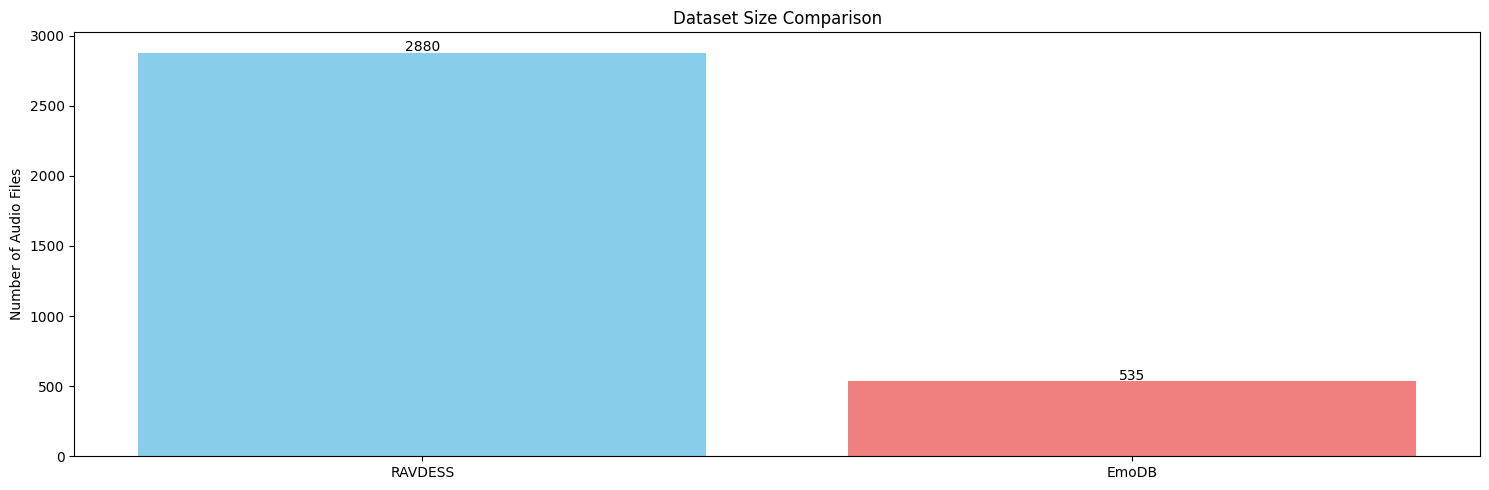

In [3]:
# Create a simple overview
fig, axes = plt.subplots(1, 1, figsize=(15, 5))

# Dataset sizes
datasets = ["RAVDESS", "EmoDB"]
file_counts = [len(ravdess_files), len(emodb_files)]

axes.bar(datasets, file_counts, color=["skyblue", "lightcoral"])
axes.set_title("Dataset Size Comparison")
axes.set_ylabel("Number of Audio Files")
for i, v in enumerate(file_counts):
    axes.text(i, v + 10, str(v), ha="center")


plt.tight_layout()
plt.show()

## Emotion Analysis

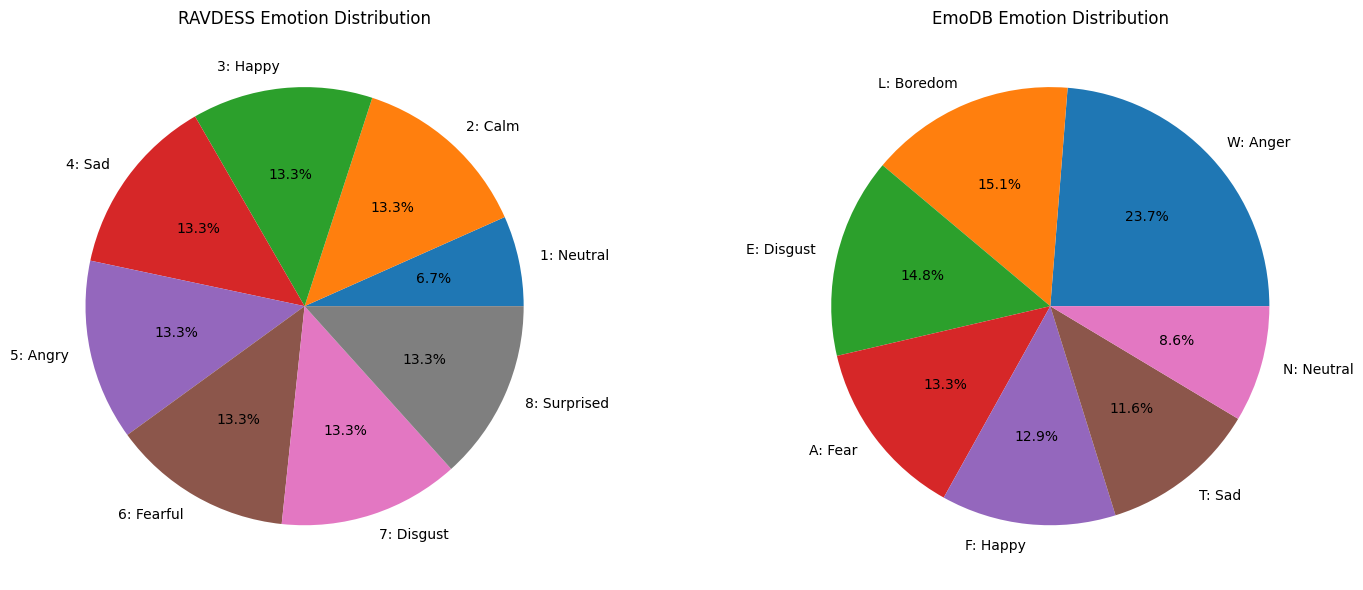

In [4]:
def parse_ravdess_emotions(files):
    """Extract emotions from RAVDESS filenames"""
    emotions = []
    for file in files:
        filename = os.path.basename(file)
        if filename.endswith(".wav"):
            emotion_code = filename.split("-")[2]
            emotions.append(emotion_code)
    return emotions


def parse_emodb_emotions(files):
    """Extract emotions from EmoDB filenames"""
    emotions = []
    for file in files:
        filename = os.path.basename(file)
        if filename.endswith(".wav"):
            emotion_code = filename[5]  # 6th character
            emotions.append(emotion_code)
    return emotions


# Parse emotions
ravdess_emotions = parse_ravdess_emotions(ravdess_files)
emodb_emotions = parse_emodb_emotions(emodb_files)

# Create emotion distribution plots
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# RAVDESS emotions
ravdess_counts = pd.Series(ravdess_emotions).value_counts().sort_index()
ravdess_labels_reference = [
    "1: Neutral",
    "2: Calm",
    "3: Happy",
    "4: Sad",
    "5: Angry",
    "6: Fearful",
    "7: Disgust",
    "8: Surprised",
]

axes[0].pie(ravdess_counts.values, labels=ravdess_labels_reference, autopct="%1.1f%%")
axes[0].set_title("RAVDESS Emotion Distribution")

# EmoDB emotions
emodb_counts = pd.Series(emodb_emotions).value_counts()
emodb_labels_reference = [
    "W: Anger",
    "L: Boredom",
    "E: Disgust",
    "A: Fear",
    "F: Happy",
    "T: Sad",
    "N: Neutral",
]

axes[1].pie(emodb_counts.values, labels=emodb_labels_reference, autopct="%1.1f%%")
axes[1].set_title("EmoDB Emotion Distribution")

plt.tight_layout()
plt.show()

## Audio Duration Analysis


=== RAVDESS Audio Info ===
Average duration: 3.71s
Duration range: 2.97s - 4.47s


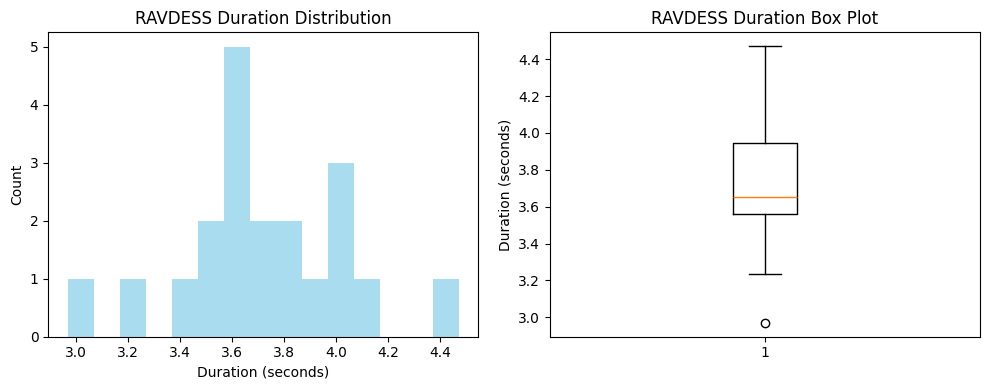


=== EmoDB Audio Info ===
Average duration: 2.79s
Duration range: 1.53s - 5.57s


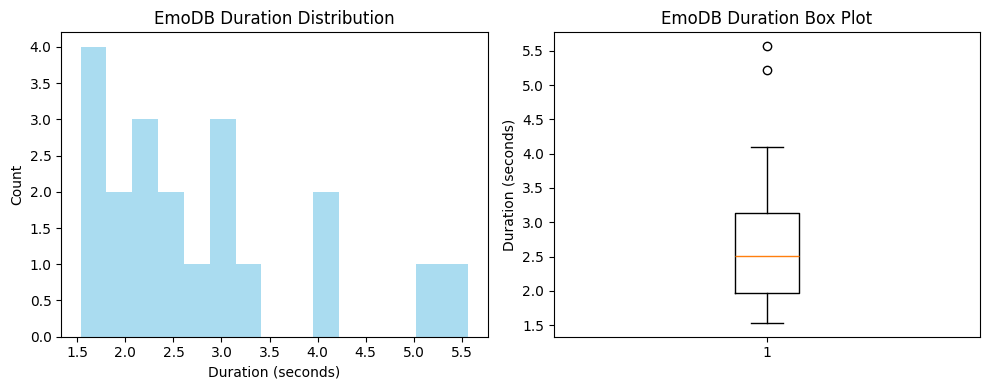

In [5]:
def get_audio_info(files, dataset_name, sample_size=20):
    """Get basic audio information"""
    print(f"\n=== {dataset_name} Audio Info ===")

    durations = []
    sample_files = np.random.choice(files, min(sample_size, len(files)), replace=False)

    for file in sample_files:
        try:
            y, sr = librosa.load(file, sr=None)
            duration = len(y) / sr
            durations.append(duration)
        except:
            continue

    if durations:
        print(f"Average duration: {np.mean(durations):.2f}s")
        print(f"Duration range: {np.min(durations):.2f}s - {np.max(durations):.2f}s")

        # Visualize durations
        plt.figure(figsize=(10, 4))
        plt.subplot(1, 2, 1)
        plt.hist(durations, bins=15, alpha=0.7, color="skyblue")
        plt.title(f"{dataset_name} Duration Distribution")
        plt.xlabel("Duration (seconds)")
        plt.ylabel("Count")

        plt.subplot(1, 2, 2)
        plt.boxplot(durations)
        plt.title(f"{dataset_name} Duration Box Plot")
        plt.ylabel("Duration (seconds)")

        plt.tight_layout()
        plt.show()


# Analyze both datasets
get_audio_info(ravdess_files, "RAVDESS")
get_audio_info(emodb_files, "EmoDB")

# Organize and partition datasets into training, validation, and testing sets

## Create Dataset DataFrame

In [6]:
def create_dataset_df(files, dataset_name, emotion_code_pos):
    """Create DataFrame with file info and emotions"""
    data = []
    for file in files:
        filename = Path(file).name
        if dataset_name == "RAVDESS":
            # Format: 03-01-01-01-01-01-01.wav
            parts = filename.replace(".wav", "").split("-")
            emotion = parts[2]
            actor = parts[6]
        else:  # EmoDB
            # Format: 03a01Fa.wav
            emotion = filename.replace(".wav", "")[5]
            actor = filename.replace(".wav", "")[:2]

        data.append(
            {
                "filename": file,
                "dataset": dataset_name,
                "emotion": emotion,
                "actor": actor,
                "filepath": os.path.join(
                    ravdess_path if dataset_name == "RAVDESS" else emodb_path, file
                ),
            }
        )

    return pd.DataFrame(data)


# Create DataFrames
ravdess_df = create_dataset_df(ravdess_files, "RAVDESS", 2)
emodb_df = create_dataset_df(emodb_files, "EmoDB", 5)

print("RAVDESS DataFrame shape:", ravdess_df.shape)
print("EmoDB DataFrame shape:", emodb_df.shape)

print(ravdess_df.head())
print(emodb_df.head())

RAVDESS DataFrame shape: (2880, 5)
EmoDB DataFrame shape: (535, 5)
                                            filename  dataset emotion actor  \
0  C:\Users\ngovi\.cache\kagglehub\datasets\uwrfk...  RAVDESS      01    01   
1  C:\Users\ngovi\.cache\kagglehub\datasets\uwrfk...  RAVDESS      01    01   
2  C:\Users\ngovi\.cache\kagglehub\datasets\uwrfk...  RAVDESS      01    01   
3  C:\Users\ngovi\.cache\kagglehub\datasets\uwrfk...  RAVDESS      01    01   
4  C:\Users\ngovi\.cache\kagglehub\datasets\uwrfk...  RAVDESS      02    01   

                                            filepath  
0  C:\Users\ngovi\.cache\kagglehub\datasets\uwrfk...  
1  C:\Users\ngovi\.cache\kagglehub\datasets\uwrfk...  
2  C:\Users\ngovi\.cache\kagglehub\datasets\uwrfk...  
3  C:\Users\ngovi\.cache\kagglehub\datasets\uwrfk...  
4  C:\Users\ngovi\.cache\kagglehub\datasets\uwrfk...  
                                            filename dataset emotion actor  \
0  C:\Users\ngovi\.cache\kagglehub\datasets\piyus.

## Train-Validation-Test Split

In [7]:
def split_dataset(df, test_size=0.2, val_size=0.2, random_state=42):
    """Split dataset into train, validation, and test sets"""
    # Stratified split: Maintains emotion distribution across splits

    # First split: train+val vs test
    train_val, test = train_test_split(
        df, test_size=test_size, random_state=random_state, stratify=df["emotion"]
    )

    # Second split: train vs val
    train, val = train_test_split(
        train_val,
        test_size=val_size / (1 - test_size),
        random_state=random_state,
        stratify=train_val["emotion"],
    )

    return train, val, test


# Split RAVDESS
ravdess_train, ravdess_val, ravdess_test = split_dataset(ravdess_df)

# Split EmoDB
emodb_train, emodb_val, emodb_test = split_dataset(
    emodb_df, test_size=0.1, val_size=0.1
)

print(
    f"RAVDESS - Train: {len(ravdess_train)}, Val: {len(ravdess_val)}, Test: {len(ravdess_test)}"
)
print(
    f"EmoDB - Train: {len(emodb_train)}, Val: {len(emodb_val)}, Test: {len(emodb_test)}"
)

RAVDESS - Train: 1728, Val: 576, Test: 576
EmoDB - Train: 427, Val: 54, Test: 54


## Save Split Information

In [8]:
# Save split information
def save_splits(train_df, val_df, test_df, dataset_name):
    """Save split information to CSV files"""
    train_df.to_csv(f"{dataset_name}_train.csv", index=False)
    val_df.to_csv(f"{dataset_name}_val.csv", index=False)
    test_df.to_csv(f"{dataset_name}_test.csv", index=False)
    print(f"{dataset_name} splits saved to CSV files")


# Save splits
save_splits(ravdess_train, ravdess_val, ravdess_test, "RAVDESS")
save_splits(emodb_train, emodb_val, emodb_test, "EmoDB")


print(ravdess_train.head())

RAVDESS splits saved to CSV files
EmoDB splits saved to CSV files
                                               filename  dataset emotion  \
492   C:\Users\ngovi\.cache\kagglehub\datasets\uwrfk...  RAVDESS      03   
2774  C:\Users\ngovi\.cache\kagglehub\datasets\uwrfk...  RAVDESS      03   
2385  C:\Users\ngovi\.cache\kagglehub\datasets\uwrfk...  RAVDESS      07   
1292  C:\Users\ngovi\.cache\kagglehub\datasets\uwrfk...  RAVDESS      05   
220   C:\Users\ngovi\.cache\kagglehub\datasets\uwrfk...  RAVDESS      06   

     actor                                           filepath  
492     09  C:\Users\ngovi\.cache\kagglehub\datasets\uwrfk...  
2774    23  C:\Users\ngovi\.cache\kagglehub\datasets\uwrfk...  
2385    16  C:\Users\ngovi\.cache\kagglehub\datasets\uwrfk...  
1292    22  C:\Users\ngovi\.cache\kagglehub\datasets\uwrfk...  
220     04  C:\Users\ngovi\.cache\kagglehub\datasets\uwrfk...  


# Normalize and clean audio files.

In [9]:
# Load a sample file to test
sample_file = ravdess_files[0]
print(f"Sample file: {sample_file}")

Sample file: C:\Users\ngovi\.cache\kagglehub\datasets\uwrfkaggler\ravdess-emotional-speech-audio\versions\1\Actor_01\03-01-01-01-01-01-01.wav


In [10]:
def load_and_inspect_audio(file_path):
    """Load audio and show basic info"""
    try:
        # Load audio
        y, sr = librosa.load(file_path, sr=None)

        print(f"Sample rate: {sr} Hz")
        print(f"Duration: {len(y)/sr:.2f} seconds")
        print(f"Audio range: {np.min(y):.3f} to {np.max(y):.3f}")
        print(f"Mean: {np.mean(y):.3f}")
        print(f"Std: {np.std(y):.3f}")

        return y, sr
    except Exception as e:
        print(f"Error loading {file_path}: {e}")
        return None, None


# Test with sample file
y, sr = load_and_inspect_audio(sample_file)

Sample rate: 48000 Hz
Duration: 3.30 seconds
Audio range: -0.038 to 0.041
Mean: 0.000
Std: 0.004


## Audio Normalization

In [11]:
def normalize_audio(y):
    """Normalize audio with minmax"""
    # Scale to [-1, 1]
    y_norm = 2 * (y - np.min(y)) / (np.max(y) - np.min(y)) - 1

    return y_norm


# Test normalization methods
if y is not None:
    y_minmax = normalize_audio(y)

    print("\nNormalization results:")
    print(f"Original: [{np.min(y):.3f}, {np.max(y):.3f}]")
    print(f"Min-max: [{np.min(y_minmax):.3f}, {np.max(y_minmax):.3f}]")


Normalization results:
Original: [-0.038, 0.041]
Min-max: [-1.000, 1.000]


## Normalization Comparison

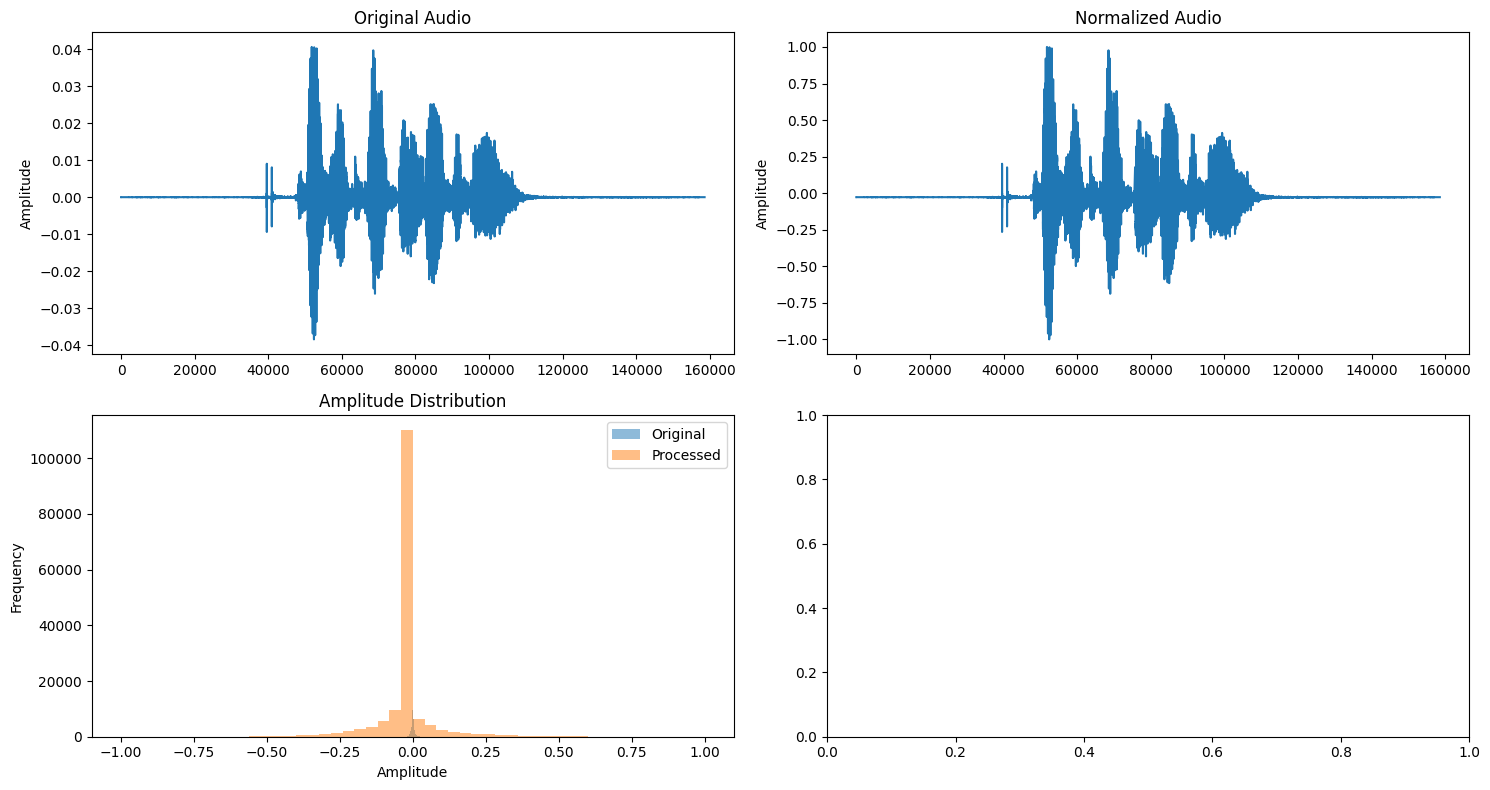

In [12]:
# Create visualization
if y is not None:
    fig, axes = plt.subplots(2, 2, figsize=(15, 8))

    # Original audio
    axes[0, 0].plot(y)
    axes[0, 0].set_title("Original Audio")
    axes[0, 0].set_ylabel("Amplitude")

    # Normalized audio
    y_norm = normalize_audio(y)
    axes[0, 1].plot(y_norm)
    axes[0, 1].set_title("Normalized Audio")
    axes[0, 1].set_ylabel("Amplitude")

    # Histogram comparison
    axes[1, 0].hist(y, bins=50, alpha=0.5, label="Original")
    axes[1, 0].hist(y_norm, bins=50, alpha=0.5, label="Processed")
    axes[1, 0].set_title("Amplitude Distribution")
    axes[1, 0].set_xlabel("Amplitude")
    axes[1, 0].set_ylabel("Frequency")
    axes[1, 0].legend()

    plt.tight_layout()
    plt.show()

## Processing

In [13]:
def process_audio_file(input_path, output_path=None, target_sr=22050):
    """Process a single audio file"""
    # check if output exists
    if output_path and os.path.exists(output_path):
        print(f"Output file {output_path} already exists. Skipping processing.")
        return None, None, False
    try:
        # Load audio
        y, sr = librosa.load(input_path, sr=target_sr)

        # Normalize
        y_norm = normalize_audio(y)

        # Save if output path provided
        if output_path:
            # Use soundfile instead of librosa.output.write_wav
            import soundfile as sf

            sf.write(output_path, y_norm, target_sr)

        return y_norm, target_sr, True
    except Exception as e:
        print(f"Error processing {input_path}: {e}")
        return None, None, False


# Test processing
if ravdess_files:
    sample_file = ravdess_files[0]
    output_file = "sample_processed.wav"

    y_processed, sr_processed, success = process_audio_file(sample_file, output_file)

    if success:
        print("Processing successful!")
        print(f"Output saved to: {output_file}")
    else:
        print("Not processed!")

Output file sample_processed.wav already exists. Skipping processing.
Not processed!


### Processing all files

In [14]:
def batch_process_files(file_list, output_dir, max_files=10):
    """Process multiple audio files from existing file list"""
    os.makedirs(output_dir, exist_ok=True)

    # Limit files for testing
    files_to_process = file_list[:max_files]

    processed = 0
    failed = 0

    print(f"Processing {len(files_to_process)} files...")

    for file_path in files_to_process:
        filename = os.path.basename(file_path)
        output_path = os.path.join(output_dir, filename)

        success = process_audio_file(file_path, output_path)[2]

        if success:
            processed += 1
            print(f"✓ {filename}")
        else:
            failed += 1
            print(f"✗ {filename}")

    print(f"\nResults: {processed} processed, {failed} failed")
    return processed, failed


# Process RAVDESS files
print("Processing RAVDESS sample files...")
ravdess_processed, ravdess_failed = batch_process_files(
    ravdess_files, "processed_ravdess", max_files=len(ravdess_files)
)

# Process EmoDB files
print("\nProcessing EmoDB sample files...")
emodb_processed, emodb_failed = batch_process_files(
    emodb_files, "processed_emodb", max_files=len(emodb_files)
)

Processing RAVDESS sample files...
Processing 2880 files...
Output file processed_ravdess\03-01-01-01-01-01-01.wav already exists. Skipping processing.
✗ 03-01-01-01-01-01-01.wav
Output file processed_ravdess\03-01-01-01-01-02-01.wav already exists. Skipping processing.
✗ 03-01-01-01-01-02-01.wav
Output file processed_ravdess\03-01-01-01-02-01-01.wav already exists. Skipping processing.
✗ 03-01-01-01-02-01-01.wav
Output file processed_ravdess\03-01-01-01-02-02-01.wav already exists. Skipping processing.
✗ 03-01-01-01-02-02-01.wav
Output file processed_ravdess\03-01-02-01-01-01-01.wav already exists. Skipping processing.
✗ 03-01-02-01-01-01-01.wav
Output file processed_ravdess\03-01-02-01-01-02-01.wav already exists. Skipping processing.
✗ 03-01-02-01-01-02-01.wav
Output file processed_ravdess\03-01-02-01-02-01-01.wav already exists. Skipping processing.
✗ 03-01-02-01-02-01-01.wav
Output file processed_ravdess\03-01-02-01-02-02-01.wav already exists. Skipping processing.
✗ 03-01-02-01-0

In [15]:
import pandas as pd
import os

# Load your existing splits
ravdess_train = pd.read_csv("RAVDESS_train.csv")
ravdess_val = pd.read_csv("RAVDESS_val.csv")
ravdess_test = pd.read_csv("RAVDESS_test.csv")

emodb_train = pd.read_csv("EmoDB_train.csv")
emodb_val = pd.read_csv("EmoDB_val.csv")
emodb_test = pd.read_csv("EmoDB_test.csv")

print("Original file paths:")
print(ravdess_train["filepath"].head())

Original file paths:
0    C:\Users\ngovi\.cache\kagglehub\datasets\uwrfk...
1    C:\Users\ngovi\.cache\kagglehub\datasets\uwrfk...
2    C:\Users\ngovi\.cache\kagglehub\datasets\uwrfk...
3    C:\Users\ngovi\.cache\kagglehub\datasets\uwrfk...
4    C:\Users\ngovi\.cache\kagglehub\datasets\uwrfk...
Name: filepath, dtype: object


In [16]:
import pandas as pd
import os

# Load the original CSV files
ravdess_train = pd.read_csv('RAVDESS_train.csv')
ravdess_val = pd.read_csv('RAVDESS_val.csv')
ravdess_test = pd.read_csv('RAVDESS_test.csv')

emodb_train = pd.read_csv('EmoDB_train.csv')
emodb_val = pd.read_csv('EmoDB_val.csv')
emodb_test = pd.read_csv('EmoDB_test.csv')

print("Original file paths:")
print(ravdess_train['filepath'].head())
print(emodb_train['filepath'].head())

Original file paths:
0    C:\Users\ngovi\.cache\kagglehub\datasets\uwrfk...
1    C:\Users\ngovi\.cache\kagglehub\datasets\uwrfk...
2    C:\Users\ngovi\.cache\kagglehub\datasets\uwrfk...
3    C:\Users\ngovi\.cache\kagglehub\datasets\uwrfk...
4    C:\Users\ngovi\.cache\kagglehub\datasets\uwrfk...
Name: filepath, dtype: object
0    C:\Users\ngovi\.cache\kagglehub\datasets\piyus...
1    C:\Users\ngovi\.cache\kagglehub\datasets\piyus...
2    C:\Users\ngovi\.cache\kagglehub\datasets\piyus...
3    C:\Users\ngovi\.cache\kagglehub\datasets\piyus...
4    C:\Users\ngovi\.cache\kagglehub\datasets\piyus...
Name: filepath, dtype: object


In [17]:
def fix_file_paths(df, dataset_name):
    """Fix file paths to point to processed files correctly in a cross-platform way."""
    df_fixed = df.copy()

    if dataset_name == "RAVDESS":
        # Use pathlib to construct the path correctly for any OS
        df_fixed["filepath"] = df_fixed["filepath"].apply(
            lambda x: str(Path("processed_ravdess") / Path(x).name)
        )
        df_fixed["filename"] = df_fixed["filename"].apply(lambda x: Path(x).name)
    else:  # EmoDB
        # Use pathlib to construct the path correctly for any OS
        df_fixed["filepath"] = df_fixed["filename"].apply(
            lambda x: str(Path("processed_emodb") / Path(x).name)
        )
        df_fixed["filename"] = df_fixed["filename"].apply(lambda x: Path(x).name)

    return df_fixed


# Fix RAVDESS files
ravdess_train_fixed = fix_file_paths(ravdess_train, "RAVDESS")
ravdess_val_fixed = fix_file_paths(ravdess_val, "RAVDESS")
ravdess_test_fixed = fix_file_paths(ravdess_test, "RAVDESS")

# Fix EmoDB files
emodb_train_fixed = fix_file_paths(emodb_train, "EmoDB")
emodb_val_fixed = fix_file_paths(emodb_val, "EmoDB")
emodb_test_fixed = fix_file_paths(emodb_test, "EmoDB")

print("Fixed file paths:")
print(ravdess_train_fixed[["filename", "filepath"]].head())
print(emodb_train_fixed[["filename", "filepath"]].head())

Fixed file paths:
                   filename                                    filepath
0  03-01-03-01-01-01-09.wav  processed_ravdess\03-01-03-01-01-01-09.wav
1  03-01-03-01-02-01-23.wav  processed_ravdess\03-01-03-01-02-01-23.wav
2  03-01-07-01-01-02-16.wav  processed_ravdess\03-01-07-01-01-02-16.wav
3  03-01-05-02-01-01-22.wav  processed_ravdess\03-01-05-02-01-01-22.wav
4  03-01-06-02-01-01-04.wav  processed_ravdess\03-01-06-02-01-01-04.wav
      filename                     filepath
0  16a01Ec.wav  processed_emodb\16a01Ec.wav
1  08a01Fd.wav  processed_emodb\08a01Fd.wav
2  13a04Ta.wav  processed_emodb\13a04Ta.wav
3  14b03Ta.wav  processed_emodb\14b03Ta.wav
4  13a05Tc.wav  processed_emodb\13a05Tc.wav


In [18]:
# Save the corrected files
ravdess_train_fixed.to_csv("RAVDESS_train_processed.csv", index=False)
ravdess_val_fixed.to_csv("RAVDESS_val_processed.csv", index=False)
ravdess_test_fixed.to_csv("RAVDESS_test_processed.csv", index=False)

emodb_train_fixed.to_csv("EmoDB_train_processed.csv", index=False)
emodb_val_fixed.to_csv("EmoDB_val_processed.csv", index=False)
emodb_test_fixed.to_csv("EmoDB_test_processed.csv", index=False)

print("Fixed CSV files saved!")

Fixed CSV files saved!


In [19]:
# Check if the files exist
sample_ravdess = ravdess_train_fixed['filepath'].iloc[0]
sample_emodb = emodb_train_fixed['filepath'].iloc[0]

print(f"RAVDESS sample file exists: {os.path.exists(sample_ravdess)}")
print(f"EmoDB sample file exists: {os.path.exists(sample_emodb)}")

print(f"\nRAVDESS sample path: {sample_ravdess}")
print(f"EmoDB sample path: {sample_emodb}")

RAVDESS sample file exists: True
EmoDB sample file exists: True

RAVDESS sample path: processed_ravdess\03-01-03-01-01-01-09.wav
EmoDB sample path: processed_emodb\16a01Ec.wav


# Extract features using Librosa.

In [20]:
ravdess_train = pd.read_csv("RAVDESS_train_processed.csv")
ravdess_val = pd.read_csv("RAVDESS_val_processed.csv")
ravdess_test = pd.read_csv("RAVDESS_test_processed.csv")

emodb_train = pd.read_csv("EmoDB_train_processed.csv")
emodb_val = pd.read_csv("EmoDB_val_processed.csv")
emodb_test = pd.read_csv("EmoDB_test_processed.csv")

print(f"RAVDESS train: {len(ravdess_train)} files")
print(f"EmoDB train: {len(emodb_train)} files")

RAVDESS train: 1728 files
EmoDB train: 427 files


In [21]:
def extract_features(file_path, sr=22050):
    """Extract audio features from a single file"""
    try:
        # Load audio
        y, sr = librosa.load(file_path, sr=sr)

        # MFCC features
        mfccs = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13)
        mfccs_mean = np.mean(mfccs, axis=1)
        mfccs_std = np.std(mfccs, axis=1)

        # Chroma features
        chroma = librosa.feature.chroma_stft(y=y, sr=sr)
        chroma_mean = np.mean(chroma, axis=1)
        chroma_std = np.std(chroma, axis=1)

        # Spectral features
        spectral_centroids = librosa.feature.spectral_centroid(y=y, sr=sr)
        spectral_rolloff = librosa.feature.spectral_rolloff(y=y, sr=sr)
        zero_crossing_rate = librosa.feature.zero_crossing_rate(y)

        # Combine features
        features = np.concatenate(
            [
                mfccs_mean,  # 13 MFCC means
                mfccs_std,  # 13 MFCC stds
                chroma_mean,  # 12 chroma means
                chroma_std,  # 12 chroma stds
                [np.mean(spectral_centroids)],  # 1 spectral centroid mean
                [np.std(spectral_centroids)],  # 1 spectral centroid std
                [np.mean(spectral_rolloff)],  # 1 spectral rolloff mean
                [np.std(spectral_rolloff)],  # 1 spectral rolloff std
                [np.mean(zero_crossing_rate)],  # 1 ZCR mean
                [np.std(zero_crossing_rate)],  # 1 ZCR std
            ]
        )

        return features, True

    except Exception as e:
        print(f"Error extracting features from {file_path}: {e}")
        return None, False


# Test feature extraction
sample_file = ravdess_train["filepath"].iloc[0]
print(f"Testing feature extraction on: {sample_file}")

features, success = extract_features(sample_file)
if success:
    print(f"Features extracted successfully!")
    print(f"Feature vector shape: {features.shape}")
    print(f"Feature vector: {features[:10]}...")  # Show first 10 features
else:
    print("Feature extraction failed!")

Testing feature extraction on: processed_ravdess\03-01-03-01-01-01-09.wav
Features extracted successfully!
Feature vector shape: (56,)
Feature vector: [-320.48574829  102.03131866   15.39442253   22.63413811   24.67813683
    8.77297115   -0.33069509   -1.46367049   -6.7077527     2.5441885 ]...


In [22]:
def extract_features_batch(df, max_files=10):
    """Extract features from multiple files"""
    features_list = []
    labels_list = []
    file_paths = []

    # Limit files for testing
    files_to_process = df.head(max_files)

    print(f"Extracting features from {len(files_to_process)} files...")

    for i, row in files_to_process.iterrows():
        file_path = row["filepath"]
        emotion = row["emotion"]

        features, success = extract_features(file_path)

        if success:
            features_list.append(features)
            labels_list.append(emotion)
            file_paths.append(file_path)
            print(f"✓ {os.path.basename(file_path)}")
        else:
            print(f"✗ {os.path.basename(file_path)}")

    print(f"Extracted features from {len(features_list)} files successfully")
    print(f"Failed to extract features from {len(file_paths) - len(features_list)} files")
    return np.array(features_list), labels_list, file_paths


# Extract features from RAVDESS train
print("Extracting RAVDESS train features...")
ravdess_features, ravdess_labels, ravdess_paths = extract_features_batch(
    ravdess_train, max_files=len(ravdess_train)
)

# Extract features from EmoDB train
print("\nExtracting EmoDB train features...")
emodb_features, emodb_labels, emodb_paths = extract_features_batch(
    emodb_train, max_files=len(emodb_train)
)

Extracting RAVDESS train features...
Extracting features from 1728 files...
✓ 03-01-03-01-01-01-09.wav
✓ 03-01-03-01-02-01-23.wav
✓ 03-01-07-01-01-02-16.wav
✓ 03-01-05-02-01-01-22.wav
✓ 03-01-06-02-01-01-04.wav
✓ 03-01-06-01-02-02-04.wav
✓ 03-01-03-01-01-01-13.wav
✓ 03-01-08-02-01-01-17.wav
✓ 03-01-04-02-02-02-20.wav
✓ 03-01-07-01-01-02-11.wav
✓ 03-01-08-01-01-01-13.wav
✓ 03-01-07-01-02-02-09.wav
✓ 03-01-02-01-02-01-13.wav
✓ 03-01-06-02-01-02-01.wav
✓ 03-01-04-02-02-02-02.wav
✓ 03-01-02-01-01-01-19.wav
✓ 03-01-08-01-02-02-15.wav
✓ 03-01-04-01-01-01-05.wav
✓ 03-01-01-01-01-01-18.wav
✓ 03-01-03-02-02-01-15.wav
✓ 03-01-06-01-01-01-05.wav
✓ 03-01-07-01-01-01-18.wav
✓ 03-01-06-01-01-01-22.wav
✓ 03-01-07-02-01-01-21.wav
✓ 03-01-07-01-02-01-06.wav
✓ 03-01-08-01-01-01-21.wav
✓ 03-01-05-02-01-02-12.wav
✓ 03-01-02-01-01-02-09.wav
✓ 03-01-07-01-02-01-16.wav
✓ 03-01-02-02-02-02-06.wav
✓ 03-01-06-01-02-01-09.wav
✓ 03-01-07-01-02-01-24.wav
✓ 03-01-01-01-01-01-09.wav
✓ 03-01-07-02-01-01-23.wav
✓ 03-0

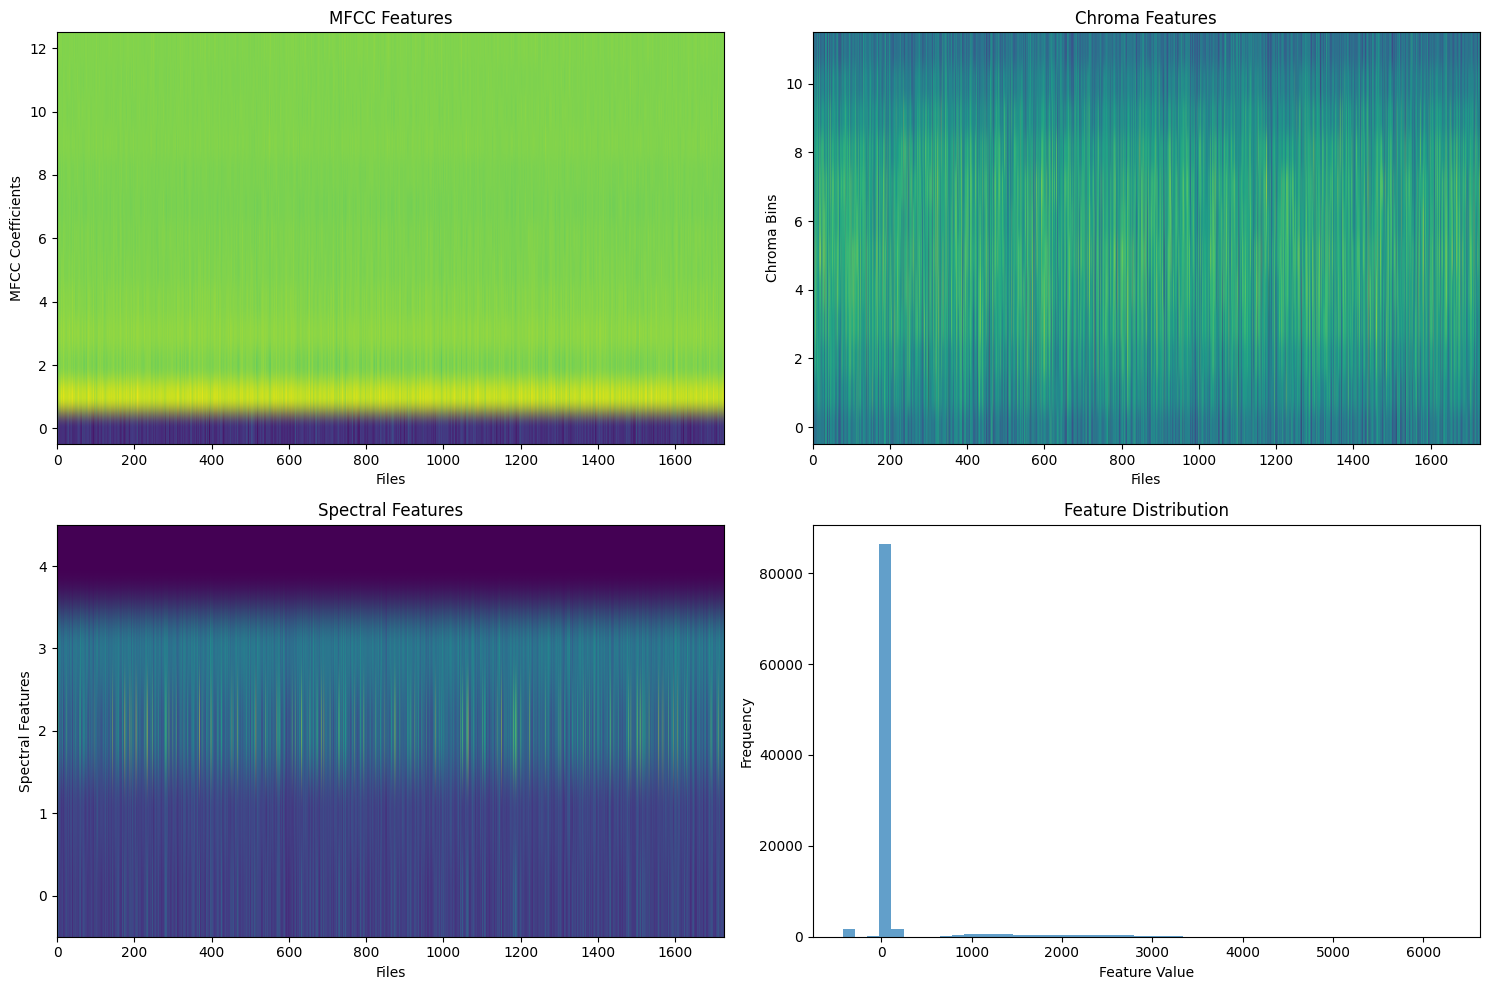

In [23]:
# Create feature visualization
if len(ravdess_features) > 0:
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))

    # MFCC features
    mfcc_data = ravdess_features[:, :13]  # First 13 are MFCC means
    axes[0, 0].imshow(mfcc_data.T, aspect="auto", origin="lower")
    axes[0, 0].set_title("MFCC Features")
    axes[0, 0].set_xlabel("Files")
    axes[0, 0].set_ylabel("MFCC Coefficients")

    # Chroma features
    chroma_data = ravdess_features[:, 26:38]  # Chroma means
    axes[0, 1].imshow(chroma_data.T, aspect="auto", origin="lower")
    axes[0, 1].set_title("Chroma Features")
    axes[0, 1].set_xlabel("Files")
    axes[0, 1].set_ylabel("Chroma Bins")

    # Spectral features
    spectral_data = ravdess_features[:, 50:55]  # Spectral features
    axes[1, 0].imshow(spectral_data.T, aspect="auto", origin="lower")
    axes[1, 0].set_title("Spectral Features")
    axes[1, 0].set_xlabel("Files")
    axes[1, 0].set_ylabel("Spectral Features")

    # Feature distribution
    axes[1, 1].hist(ravdess_features.flatten(), bins=50, alpha=0.7)
    axes[1, 1].set_title("Feature Distribution")
    axes[1, 1].set_xlabel("Feature Value")
    axes[1, 1].set_ylabel("Frequency")

    plt.tight_layout()
    plt.show()

In [24]:
def save_features(features, labels, file_paths, filename):
    """Save extracted features to file"""
    feature_data = {
        'filepath': file_paths,
        'emotion': labels,
        'features': [features[i].tolist() for i in range(len(features))]
    }
    
    df = pd.DataFrame(feature_data)
    df.to_csv(filename, index=False)
    print(f"Features saved to {filename}")

# Save features
if len(ravdess_features) > 0:
    save_features(ravdess_features, ravdess_labels, ravdess_paths, 'ravdess_features.csv')

if len(emodb_features) > 0:
    save_features(emodb_features, emodb_labels, emodb_paths, 'emodb_features.csv')

Features saved to ravdess_features.csv
Features saved to emodb_features.csv


## Feature statistics

In [25]:
# Analyze feature statistics
if len(ravdess_features) > 0:
    print("\n=== RAVDESS Feature Statistics ===")
    print(f"Feature vector shape: {ravdess_features.shape}")
    print(f"Number of features: {ravdess_features.shape[1]}")
    print(
        f"Feature range: [{np.min(ravdess_features):.3f}, {np.max(ravdess_features):.3f}]"
    )
    print(f"Feature mean: {np.mean(ravdess_features):.3f}")
    print(f"Feature std: {np.std(ravdess_features):.3f}")


# Analyze feature statistics
if len(emodb_features) > 0:
    print("\n=== EmoDB Feature Statistics ===")
    print(f"Feature vector shape: {emodb_features.shape}")
    print(f"Number of features: {emodb_features.shape[1]}")
    print(
        f"Feature range: [{np.min(emodb_features):.3f}, {np.max(emodb_features):.3f}]"
    )
    print(f"Feature mean: {np.mean(emodb_features):.3f}")
    print(f"Feature std: {np.std(emodb_features):.3f}")


=== RAVDESS Feature Statistics ===
Feature vector shape: (1728, 56)
Number of features: 56
Feature range: [-424.383, 6291.020]
Feature mean: 132.008
Feature std: 510.239

=== EmoDB Feature Statistics ===
Feature vector shape: (427, 56)
Number of features: 56
Feature range: [-340.137, 4770.203]
Feature mean: 130.635
Feature std: 508.148


# Features visualizations

In [26]:
ravdess_features = pd.read_csv("ravdess_features.csv")
emodb_features = pd.read_csv("emodb_features.csv")

print("Original data structure:")
print(ravdess_features.head())

Original data structure:
                                     filepath  emotion  \
0  processed_ravdess\03-01-03-01-01-01-09.wav        3   
1  processed_ravdess\03-01-03-01-02-01-23.wav        3   
2  processed_ravdess\03-01-07-01-01-02-16.wav        7   
3  processed_ravdess\03-01-05-02-01-01-22.wav        5   
4  processed_ravdess\03-01-06-02-01-01-04.wav        6   

                                            features  
0  [-320.4857482910156, 102.03131866455078, 15.39...  
1  [-365.70037841796875, 52.30513000488281, -0.02...  
2  [-354.28839111328125, 63.13930892944336, 5.109...  
3  [-338.6822204589844, 40.00629806518555, -8.913...  
4  [-307.78271484375, 12.771662712097168, -12.417...  


## Convert Features to Proper Format

In [27]:
def convert_features_to_array(df):
    """Convert string features to numpy arrays"""
    df_converted = df.copy()

    # Convert features from string to list, then to numpy array
    df_converted["features_array"] = df_converted["features"].apply(
        lambda x: np.array(ast.literal_eval(x)) if isinstance(x, str) else x
    )

    return df_converted


# Convert both datasets
ravdess_converted = convert_features_to_array(ravdess_features)
emodb_converted = convert_features_to_array(emodb_features)

print("Converted data structure:")
print(f"RAVDESS features shape: {ravdess_converted['features_array'].iloc[0].shape}")
print(f"EmoDB features shape: {emodb_converted['features_array'].iloc[0].shape}")

Converted data structure:
RAVDESS features shape: (56,)
EmoDB features shape: (56,)


## Create Feature DataFrame

In [28]:
def create_feature_dataframe(df, dataset_name):
    """Create proper feature DataFrame"""
    # Extract features into separate columns
    features_list = []
    for features in df["features_array"]:
        features_list.append(features)

    # Create DataFrame with features
    feature_df = pd.DataFrame(features_list)
    feature_df.columns = [f"feature_{i}" for i in range(feature_df.shape[1])]

    # Add emotion and filepath
    feature_df["emotion"] = df["emotion"].values
    feature_df["filepath"] = df["filepath"].values
    feature_df["dataset"] = dataset_name

    return feature_df


# Create feature DataFrames
ravdess_feature_df = create_feature_dataframe(ravdess_converted, "RAVDESS")
emodb_feature_df = create_feature_dataframe(emodb_converted, "EmoDB")

print(f"RAVDESS feature DataFrame shape: {ravdess_feature_df.shape}")
print(f"EmoDB feature DataFrame shape: {emodb_feature_df.shape}")
print(ravdess_feature_df.head())


RAVDESS feature DataFrame shape: (1728, 59)
EmoDB feature DataFrame shape: (427, 59)
    feature_0   feature_1  feature_2  feature_3  feature_4  feature_5  \
0 -320.485748  102.031319  15.394423  22.634138  24.678137   8.772971   
1 -365.700378   52.305130  -0.026466  10.577127  11.870023   1.130281   
2 -354.288391   63.139309   5.109401  13.015352   0.229097   4.931804   
3 -338.682220   40.006298  -8.913127   6.741939   2.058925  -7.412462   
4 -307.782715   12.771663 -12.417810   5.491361  -1.259862   0.770396   

   feature_6  feature_7  feature_8  feature_9  ...  feature_49   feature_50  \
0  -0.330695  -1.463670  -6.707753   2.544188  ...    0.298119   994.773845   
1   0.331854  -1.905840  -5.493265   2.666674  ...    0.304996   903.776561   
2  -3.485385  -6.094250   1.577608   7.464976  ...    0.310877  1110.612466   
3  -3.250018  -4.488398  -6.365468   4.963514  ...    0.285870  1312.699604   
4  -1.889484 -12.891840  -2.295711   5.569106  ...    0.295551  2253.661612   

 

## Feature Histograms

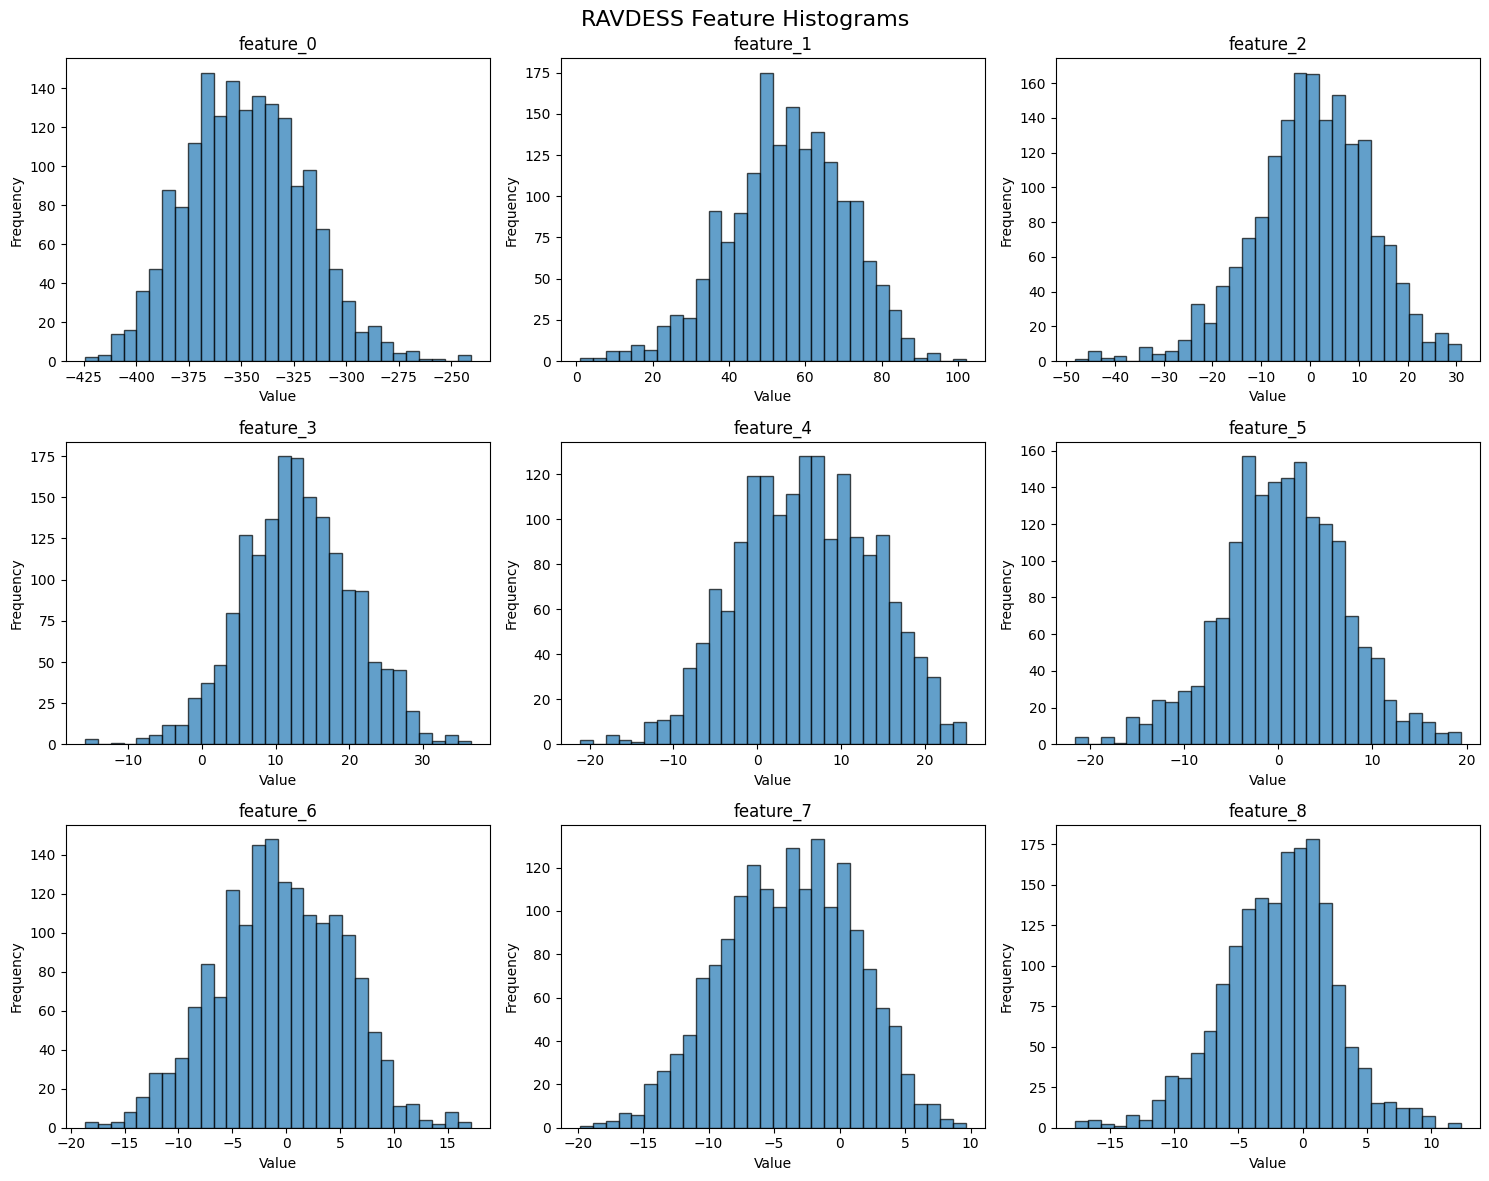

In [29]:
# Plot histograms for first 9 features
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()

for i in range(9):  # First 9 features
    col = f"feature_{i}"
    axes[i].hist(ravdess_feature_df[col], bins=30, alpha=0.7, edgecolor="black")
    axes[i].set_title(f"{col}")
    axes[i].set_xlabel("Value")
    axes[i].set_ylabel("Frequency")

plt.suptitle("RAVDESS Feature Histograms", fontsize=16)
plt.tight_layout()
plt.show()

## Compare RAVDESS vs EmoDB

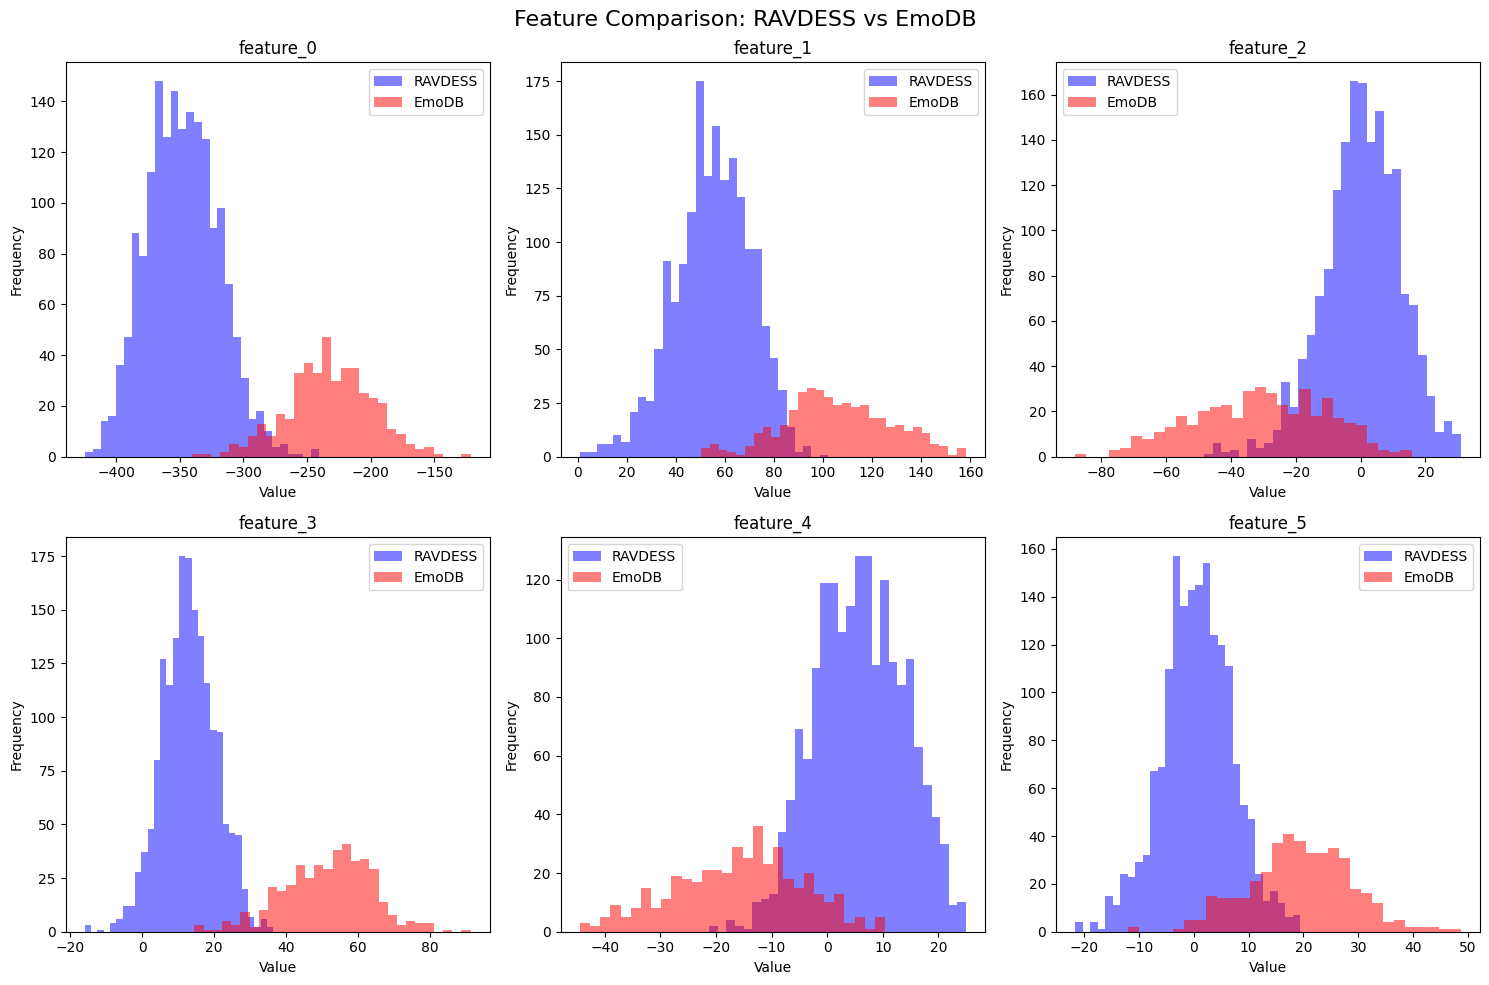

In [30]:
# Compare first 6 features between datasets
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for i in range(6):  # First 6 features
    col = f"feature_{i}"

    # RAVDESS
    axes[i].hist(
        ravdess_feature_df[col], bins=30, alpha=0.5, label="RAVDESS", color="blue"
    )

    # EmoDB
    axes[i].hist(emodb_feature_df[col], bins=30, alpha=0.5, label="EmoDB", color="red")

    axes[i].set_title(f"{col}")
    axes[i].set_xlabel("Value")
    axes[i].set_ylabel("Frequency")
    axes[i].legend()

plt.suptitle("Feature Comparison: RAVDESS vs EmoDB", fontsize=16)
plt.tight_layout()
plt.show()

## Heatmap

In [31]:
def create_feature_matrix(df, max_samples=100):
    """Create feature matrix for heatmap"""
    # Limit samples for visualization
    df_sample = df.head(max_samples)

    # Extract features into matrix
    features_matrix = []
    for features in df_sample["features_array"]:
        features_matrix.append(features)

    return np.array(features_matrix)


# Create feature matrices
ravdess_matrix = create_feature_matrix(ravdess_converted, max_samples=50)
emodb_matrix = create_feature_matrix(emodb_converted, max_samples=50)

print(f"RAVDESS matrix shape: {ravdess_matrix.shape}")
print(f"EmoDB matrix shape: {emodb_matrix.shape}")

RAVDESS matrix shape: (50, 56)
EmoDB matrix shape: (50, 56)


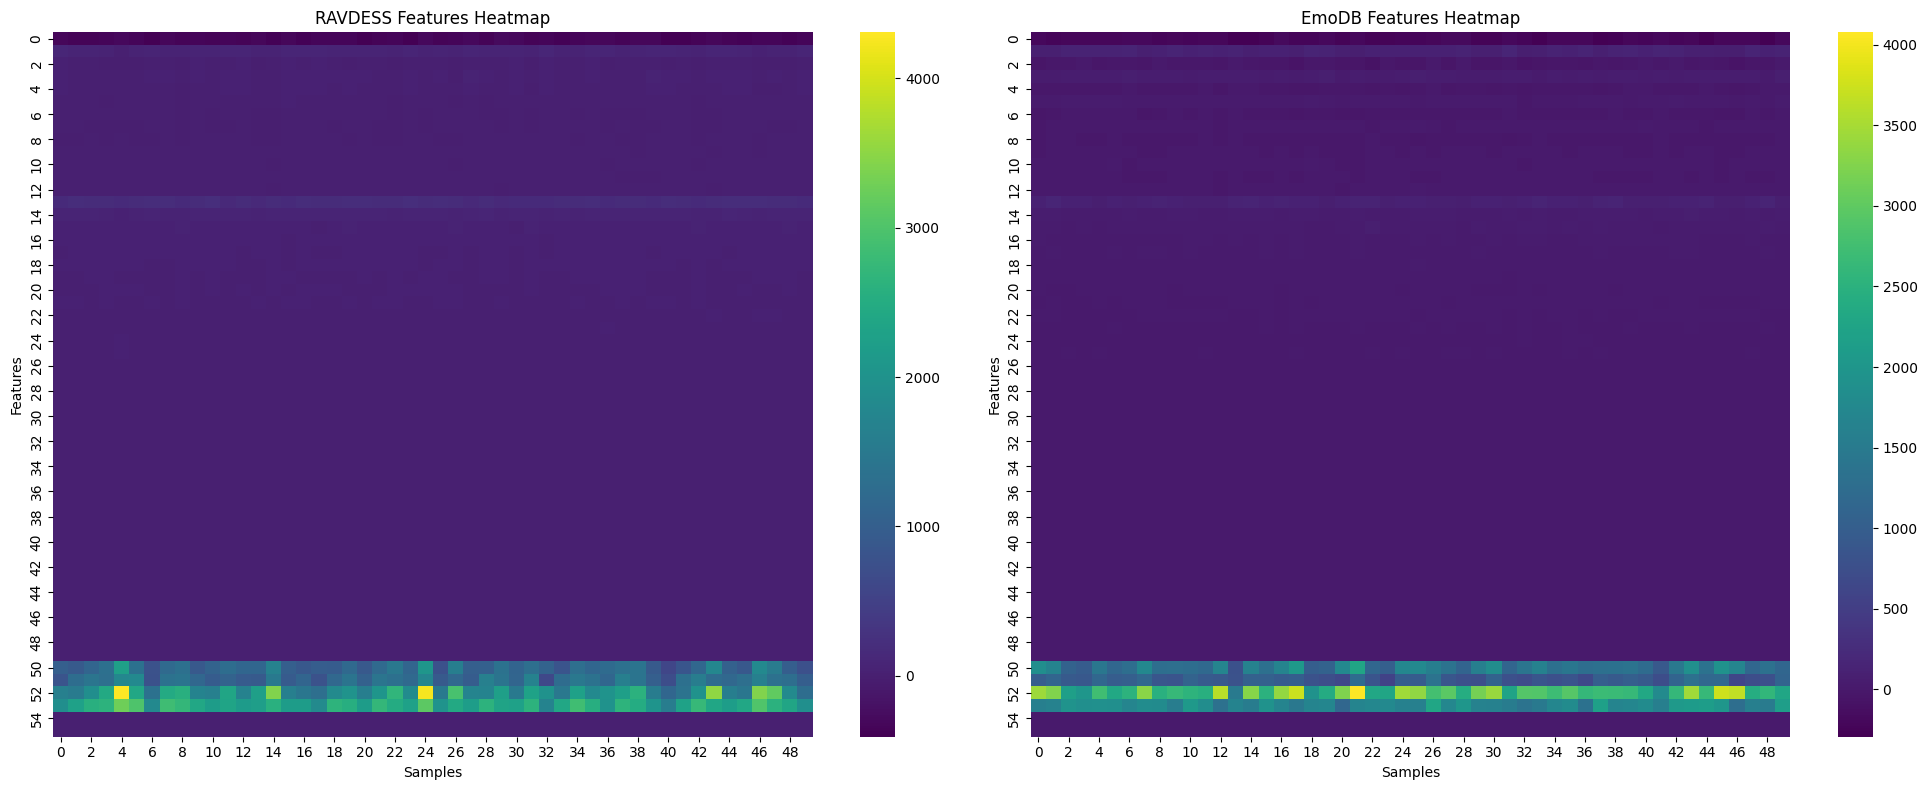

In [32]:
# Create feature heatmap
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# RAVDESS heatmap
sns.heatmap(ravdess_matrix.T, cmap="viridis", ax=axes[0], cbar=True)
axes[0].set_title("RAVDESS Features Heatmap")
axes[0].set_xlabel("Samples")
axes[0].set_ylabel("Features")

# EmoDB heatmap
sns.heatmap(emodb_matrix.T, cmap="viridis", ax=axes[1], cbar=True)
axes[1].set_title("EmoDB Features Heatmap")
axes[1].set_xlabel("Samples")
axes[1].set_ylabel("Features")

plt.tight_layout()
plt.show()

## Feature Correlation Heatmap

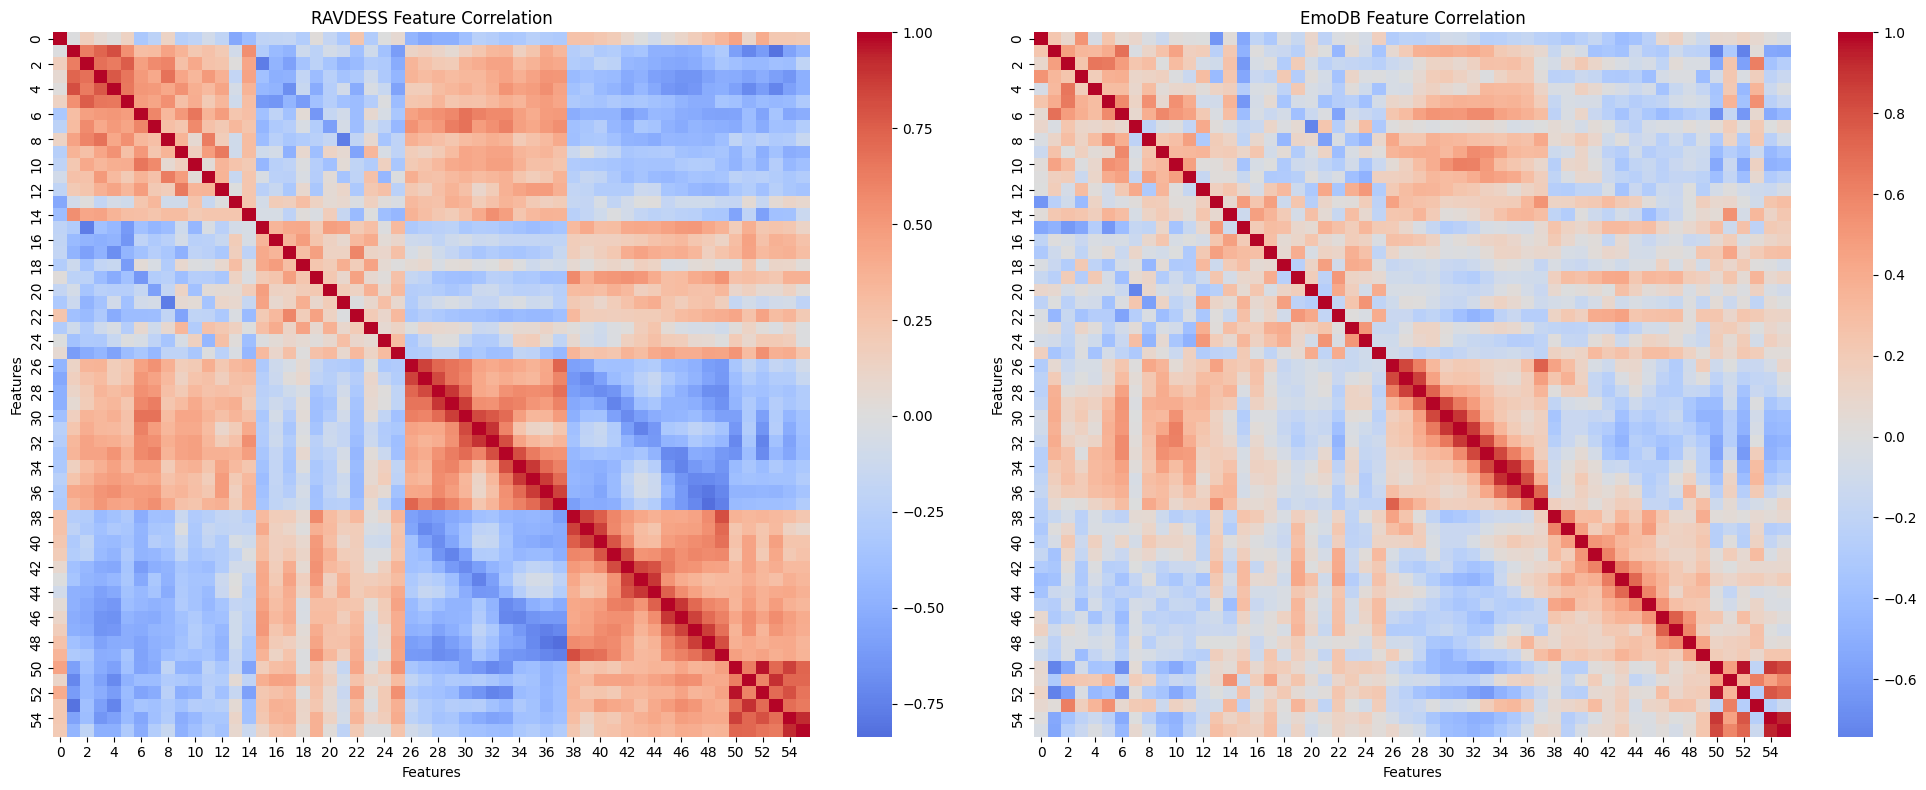

In [33]:
# Create correlation heatmap
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# RAVDESS correlation
ravdess_corr = np.corrcoef(ravdess_matrix.T)
sns.heatmap(ravdess_corr, cmap="coolwarm", center=0, ax=axes[0], cbar=True)
axes[0].set_title("RAVDESS Feature Correlation")
axes[0].set_xlabel("Features")
axes[0].set_ylabel("Features")

# EmoDB correlation
emodb_corr = np.corrcoef(emodb_matrix.T)
sns.heatmap(emodb_corr, cmap="coolwarm", center=0, ax=axes[1], cbar=True)
axes[1].set_title("EmoDB Feature Correlation")
axes[1].set_xlabel("Features")
axes[1].set_ylabel("Features")

plt.tight_layout()
plt.show()

# Balance classes


=== RAVDESS Class Distribution ===
emotion
3    231
2    231
5    230
7    230
6    230
8    230
4    230
1    116
Name: count, dtype: int64

Percentages:
3: 231 (13.4%)
2: 231 (13.4%)
5: 230 (13.3%)
7: 230 (13.3%)
6: 230 (13.3%)
8: 230 (13.3%)
4: 230 (13.3%)
1: 116 (6.7%)
['1: Neutral', '2: Calm', '3: Happy', '4: Sad', '5: Angry', '6: Fearful', '7: Disgust', '8: Surprised']


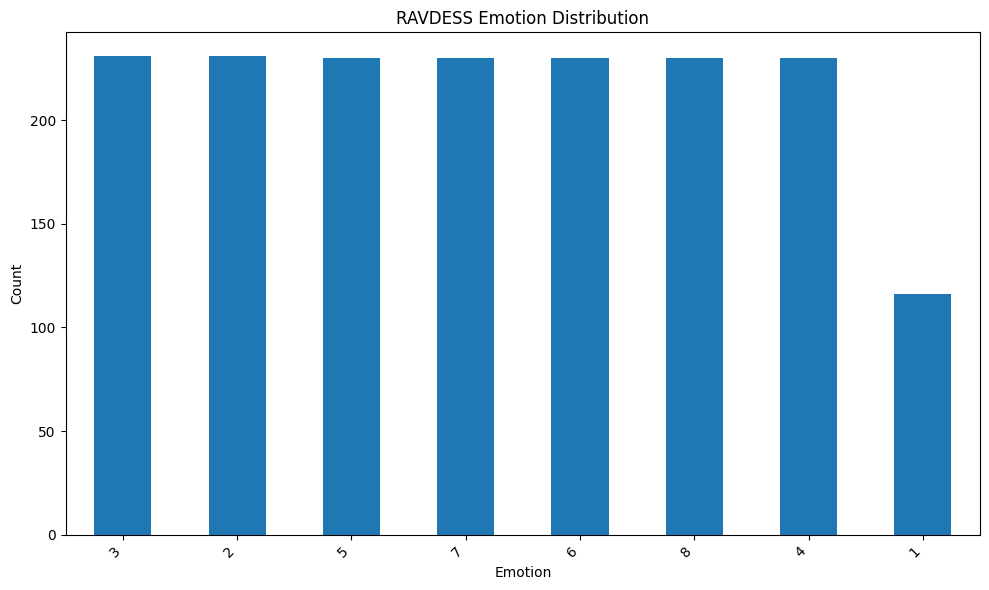


=== EmoDB Class Distribution ===
emotion
W    101
L     65
N     63
F     57
A     55
T     50
E     36
Name: count, dtype: int64

Percentages:
W: 101 (23.7%)
L: 65 (15.2%)
N: 63 (14.8%)
F: 57 (13.3%)
A: 55 (12.9%)
T: 50 (11.7%)
E: 36 (8.4%)
['W: Anger', 'L: Boredom', 'E: Disgust', 'A: Fear', 'F: Happy', 'T: Sad', 'N: Neutral']


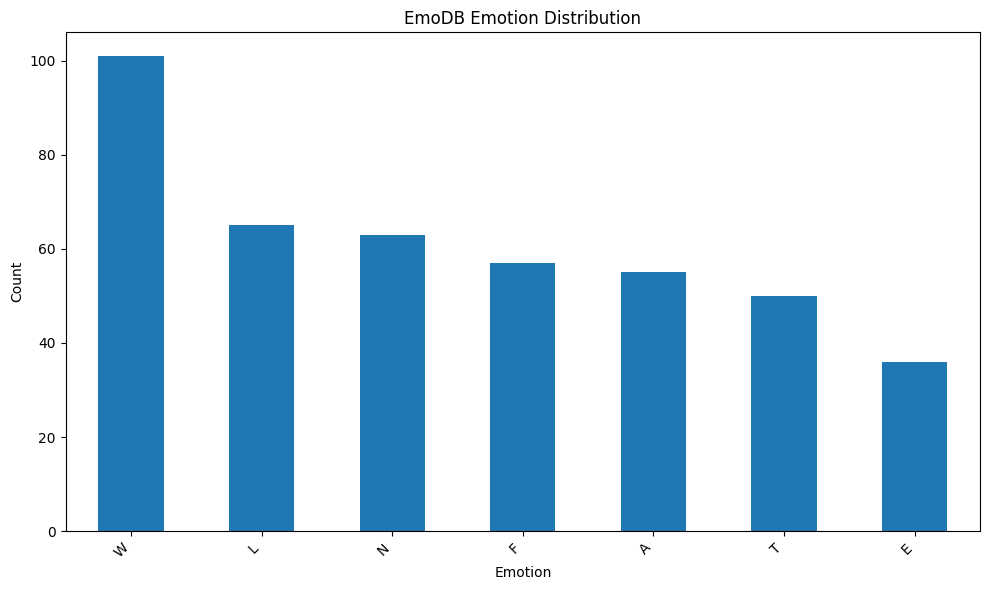

In [34]:
def analyze_class_distribution(df, dataset_name, reference_labels):
    """Analyze class distribution in dataset"""
    print(f"\n=== {dataset_name} Class Distribution ===")

    # Count emotions
    emotion_counts = df["emotion"].value_counts()
    print(emotion_counts)

    # Calculate percentages
    total = len(df)
    print(f"\nPercentages:")
    for emotion, count in emotion_counts.items():
        percentage = (count / total) * 100
        print(f"{emotion}: {count} ({percentage:.1f}%)")
    print(reference_labels)

    # Visualize distribution
    plt.figure(figsize=(10, 6))
    ax = emotion_counts.plot(kind="bar")
    plt.title(f"{dataset_name} Emotion Distribution")
    plt.xlabel("Emotion")
    plt.ylabel("Count")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

    return emotion_counts


# Analyze both datasets
ravdess_dist = analyze_class_distribution(
    ravdess_features, "RAVDESS", ravdess_labels_reference
)
emodb_dist = analyze_class_distribution(emodb_features, "EmoDB", emodb_labels_reference)

## Oversampling

In [35]:
def oversampling(df, target_samples=1000):
    """Simple oversampling to balance classes"""
    # Get emotion counts
    emotion_counts = df["emotion"].value_counts()

    # Find the maximum count
    max_count = max(emotion_counts.values)
    target_count = min(target_samples, max_count)

    # Oversample each emotion
    oversampled_data = []

    for emotion in emotion_counts.index:
        emotion_data = df[df["emotion"] == emotion]

        if len(emotion_data) < target_count:
            # Oversample
            oversampled = resample(
                emotion_data, n_samples=target_count, random_state=42, replace=True
            )
            oversampled_data.append(oversampled)
        else:
            # Use original data
            oversampled_data.append(emotion_data)

    # Combine all oversampled data
    balanced_df = pd.concat(oversampled_data, ignore_index=True)

    return balanced_df


# Apply simple oversampling
ravdess_balanced = oversampling(ravdess_converted, target_samples=500)
emodb_balanced = oversampling(emodb_converted, target_samples=200)

print(f"RAVDESS balanced: {len(ravdess_balanced)} samples")
print(f"EmoDB balanced: {len(emodb_balanced)} samples")

RAVDESS balanced: 1848 samples
EmoDB balanced: 707 samples


## Calculate Class Weights

In [36]:
def calculate_class_weights(df):
    """Calculate class weights for weighted loss functions"""
    # Count emotions
    emotion_counts = df["emotion"].value_counts()

    # Calculate weights (inverse of frequency)
    total_samples = len(df)
    num_classes = len(emotion_counts)

    weights = {}
    for emotion, count in emotion_counts.items():
        weight = total_samples / (num_classes * count)
        weights[emotion] = weight

    return weights


# Calculate weights for both datasets
ravdess_weights = calculate_class_weights(ravdess_converted)
emodb_weights = calculate_class_weights(emodb_converted)

print("RAVDESS class weights:")
for emotion, weight in ravdess_weights.items():
    print(f"{emotion}: {weight:.3f}")

print("\nEmoDB class weights:")
for emotion, weight in emodb_weights.items():
    print(f"{emotion}: {weight:.3f}")

RAVDESS class weights:
3: 0.935
2: 0.935
5: 0.939
7: 0.939
6: 0.939
8: 0.939
4: 0.939
1: 1.862

EmoDB class weights:
W: 0.604
L: 0.938
N: 0.968
F: 1.070
A: 1.109
T: 1.220
E: 1.694


## Save Balanced Datasets

In [37]:
def save_balanced_dataset(df, filename):
    """Save balanced dataset to CSV"""
    # Convert features back to string format for CSV
    df_save = df.copy()
    df_save['features'] = df_save['features_array'].apply(lambda x: x.tolist())
    df_save = df_save.drop('features_array', axis=1)
    
    # Save to CSV
    df_save.to_csv(filename, index=False)
    print(f"Balanced dataset saved to {filename}")

# Save balanced datasets
save_balanced_dataset(ravdess_balanced, 'ravdess_balanced.csv')
save_balanced_dataset(emodb_balanced, 'emodb_balanced.csv')

Balanced dataset saved to ravdess_balanced.csv
Balanced dataset saved to emodb_balanced.csv


In [38]:
def create_weighted_loss_function(class_weights):
    """Create weighted loss function for neural networks"""
    import tensorflow as tf

    def weighted_categorical_crossentropy(y_true, y_pred):
        # Convert class weights to tensor
        weight_tensor = tf.constant(
            [class_weights.get(f"class_{i}", 1.0) for i in range(len(class_weights))]
        )

        # Calculate weighted loss
        loss = tf.keras.losses.categorical_crossentropy(y_true, y_pred)
        weights = tf.gather(weight_tensor, tf.argmax(y_true, axis=1))

        return loss * weights

    return weighted_categorical_crossentropy


# Create weighted loss functions
ravdess_weighted_loss = create_weighted_loss_function(ravdess_weights)
emodb_weighted_loss = create_weighted_loss_function(emodb_weights)

print("Weighted loss functions created")

Weighted loss functions created


# Create feature-label mappings for model input

In [39]:
ravdess_balanced = pd.read_csv('ravdess_balanced.csv')
emodb_balanced = pd.read_csv('emodb_balanced.csv')

print(f"RAVDESS balanced: {len(ravdess_balanced)} samples")
print(f"EmoDB balanced: {len(emodb_balanced)} samples")

# Convert both datasets
ravdess_converted = convert_features_to_array(ravdess_balanced)
emodb_converted = convert_features_to_array(emodb_balanced)

print("Features converted to arrays")

RAVDESS balanced: 1848 samples
EmoDB balanced: 707 samples
Features converted to arrays


## Create Feature-Label Mappings

In [40]:
ravdess_emotion_mapping = {
    "1": "Neutral",
    "2": "Calm",
    "3": "Happy",
    "4": "Sad",
    "5": "Angry",
    "6": "Fearful",
    "7": "Disgust",
    "8": "Surprised",
}


emodb_emotion_mapping = {
    "W": "Anger",
    "L": "Boredom",
    "E": "Disgust",
    "A": "Fear",
    "F": "Happy",
    "T": "Sad",
    "N": "Neutral",
}


def create_feature_label_mappings(df, dataset_name):
    """Create feature-label mappings for model input"""

    # Extract features and labels
    features_list = []
    labels = []

    for _, row in df.iterrows():
        features_list.append(row["features_array"])
        labels.append(row["emotion"])

    # Convert to numpy arrays
    X = np.array(features_list)
    y = np.array(labels)

    le = LabelEncoder()
    y = le.fit_transform(y)

    # Create label mappings with string keys
    label_mapping = {}
    reverse_mapping = {}

    for i, emotion in enumerate(le.classes_):
        label_mapping[str(emotion)] = int(i)  # Convert to string key and int value
        if dataset_name == "RAVDESS":
            reverse_mapping[int(i)] = ravdess_emotion_mapping[str(emotion)]
        elif dataset_name == "EmoDB":
            reverse_mapping[int(i)] = emodb_emotion_mapping[str(emotion)]

    # Save label mappings
    with open(f"{dataset_name}_label_mapping.json", "w") as f:
        json.dump(label_mapping, f, indent=2)

    with open(f"{dataset_name}_reverse_mapping.json", "w") as f:
        json.dump(reverse_mapping, f, indent=2)

    print("Label mappings saved to JSON files!")

    print(f"\n=== {dataset_name} Feature-Label Mappings ===")
    print(f"Features shape: {X.shape}")
    print(f"Labels shape: {y.shape}")
    print(f"Unique labels: {le.classes_}")
    print(f"Label distribution: {np.bincount(y)}")
    print(f"Encoded labels: {np.unique(y)}")
    print(f"Label mapping: {label_mapping}")

    return X, y, le


# Create mappings for both datasets
ravdess_X, ravdess_y, ravdess_le = create_feature_label_mappings(
    ravdess_converted, "RAVDESS"
)
emodb_X, emodb_y, emodb_le = create_feature_label_mappings(emodb_converted, "EmoDB")

Label mappings saved to JSON files!

=== RAVDESS Feature-Label Mappings ===
Features shape: (1848, 56)
Labels shape: (1848,)
Unique labels: [1 2 3 4 5 6 7 8]
Label distribution: [231 231 231 231 231 231 231 231]
Encoded labels: [0 1 2 3 4 5 6 7]
Label mapping: {'1': 0, '2': 1, '3': 2, '4': 3, '5': 4, '6': 5, '7': 6, '8': 7}
Label mappings saved to JSON files!

=== EmoDB Feature-Label Mappings ===
Features shape: (707, 56)
Labels shape: (707,)
Unique labels: ['A' 'E' 'F' 'L' 'N' 'T' 'W']
Label distribution: [101 101 101 101 101 101 101]
Encoded labels: [0 1 2 3 4 5 6]
Label mapping: {'A': 0, 'E': 1, 'F': 2, 'L': 3, 'N': 4, 'T': 5, 'W': 6}


## Scale Features

In [41]:
def scale_features(X, dataset_name):
    """Scale features using StandardScaler"""

    # Create scaler
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    print(f"\n=== {dataset_name} Feature Scaling ===")
    print(f"Original features range: [{np.min(X):.3f}, {np.max(X):.3f}]")
    print(f"Scaled features range: [{np.min(X_scaled):.3f}, {np.max(X_scaled):.3f}]")
    print(f"Scaled features mean: {np.mean(X_scaled):.3f}")
    print(f"Scaled features std: {np.std(X_scaled):.3f}")

    return X_scaled, scaler


# Scale features for both datasets
ravdess_X_scaled, ravdess_scaler = scale_features(ravdess_X, "RAVDESS")
emodb_X_scaled, emodb_scaler = scale_features(emodb_X, "EmoDB")


=== RAVDESS Feature Scaling ===
Original features range: [-424.383, 6291.020]
Scaled features range: [-5.287, 6.374]
Scaled features mean: -0.000
Scaled features std: 1.000

=== EmoDB Feature Scaling ===
Original features range: [-340.137, 4770.203]
Scaled features range: [-4.014, 4.243]
Scaled features mean: 0.000
Scaled features std: 1.000


## Create Splits

In [42]:
def create_splits(X, y, test_size=0.2, val_size=0.2, random_state=42):
    """Create train-validation-test splits"""

    # First split: train+val vs test
    X_train_val, X_test, y_train_val, y_test = train_test_split(
        X, y, test_size=test_size, random_state=random_state, stratify=y
    )

    # Second split: train vs val
    X_train, X_val, y_train, y_val = train_test_split(
        X_train_val,
        y_train_val,
        test_size=val_size / (1 - test_size),
        random_state=random_state,
        stratify=y_train_val,
    )

    return X_train, X_val, X_test, y_train, y_val, y_test


# Create splits for RAVDESS
(
    ravdess_X_train,
    ravdess_X_val,
    ravdess_X_test,
    ravdess_y_train,
    ravdess_y_val,
    ravdess_y_test,
) = create_splits(ravdess_X_scaled, ravdess_y)

# Create splits for EmoDB
emodb_X_train, emodb_X_val, emodb_X_test, emodb_y_train, emodb_y_val, emodb_y_test = (
    create_splits(emodb_X_scaled, emodb_y, test_size=0.1, val_size=0.1)
)

print(f"\n=== Dataset Splits ===")
print(
    f"RAVDESS - Train: {ravdess_X_train.shape[0]}, Val: {ravdess_X_val.shape[0]}, Test: {ravdess_X_test.shape[0]}"
)
print(
    f"EmoDB - Train: {emodb_X_train.shape[0]}, Val: {emodb_X_val.shape[0]}, Test: {emodb_X_test.shape[0]}"
)


=== Dataset Splits ===
RAVDESS - Train: 1108, Val: 370, Test: 370
EmoDB - Train: 565, Val: 71, Test: 71


## Save Mappings

In [43]:
def save_mappings(X_train, X_val, X_test, y_train, y_val, y_test, dataset_name):
    """Save feature-label mappings to files"""
    
    # Save features
    np.save(f'{dataset_name}_X_train.npy', X_train)
    np.save(f'{dataset_name}_X_val.npy', X_val)
    np.save(f'{dataset_name}_X_test.npy', X_test)
    
    # Save labels
    np.save(f'{dataset_name}_y_train.npy', y_train)
    np.save(f'{dataset_name}_y_val.npy', y_val)
    np.save(f'{dataset_name}_y_test.npy', y_test)
    
    print(f"{dataset_name} mappings saved to .npy files")

# Save mappings for all datasets
save_mappings(ravdess_X_train, ravdess_X_val, ravdess_X_test, ravdess_y_train, ravdess_y_val, ravdess_y_test, 'ravdess')
save_mappings(emodb_X_train, emodb_X_val, emodb_X_test, emodb_y_train, emodb_y_val, emodb_y_test, 'emodb')

ravdess mappings saved to .npy files
emodb mappings saved to .npy files


# Implement a sequential model with dense layers

In [44]:
X_train = np.load("ravdess_X_train.npy")
X_val = np.load("ravdess_X_val.npy")
X_test = np.load("ravdess_X_test.npy")
y_train = np.load("ravdess_y_train.npy")
y_val = np.load("ravdess_y_val.npy")
y_test = np.load("ravdess_y_test.npy")


print(f"Training data shape: {X_train.shape}")
print(f"Validation data shape: {X_val.shape}")
print(f"Test data shape: {X_test.shape}")
print(f"Number of classes: {len(np.unique(y_train))}")

Training data shape: (1108, 56)
Validation data shape: (370, 56)
Test data shape: (370, 56)
Number of classes: 8


## Convert Labels to Categorical

In [45]:
# Convert labels to categorical for multi-class classification
num_classes = len(np.unique(y_train))
y_train_cat = keras.utils.to_categorical(y_train, num_classes)
y_val_cat = keras.utils.to_categorical(y_val, num_classes)
y_test_cat = keras.utils.to_categorical(y_test, num_classes)

print(f"Training labels shape: {y_train_cat.shape}")
print(f"Validation labels shape: {y_val_cat.shape}")
print(f"Test labels shape: {y_test_cat.shape}")

Training labels shape: (1108, 8)
Validation labels shape: (370, 8)
Test labels shape: (370, 8)


## Hyperparameter Grid


In [46]:
param_grid = {
    'hidden_layers': [2, 3, 4],
    'hidden_units': [64, 128, 256],
    'dropout_rate': [0.2, 0.3, 0.4],
    'learning_rate': [0.001, 0.01, 0.1],
    'batch_size': [16, 32, 64],
    'activation': ['relu', 'tanh', 'elu']
}

print("Hyperparameter grid:")
for param, values in param_grid.items():
    print(f"{param}: {values}")


Hyperparameter grid:
hidden_layers: [2, 3, 4]
hidden_units: [64, 128, 256]
dropout_rate: [0.2, 0.3, 0.4]
learning_rate: [0.001, 0.01, 0.1]
batch_size: [16, 32, 64]
activation: ['relu', 'tanh', 'elu']


## Create model

In [47]:
def create_model(
    hidden_layers, hidden_units, dropout_rate, activation, input_shape, num_classes
):
    """Create model with specified hyperparameters"""

    model = keras.Sequential()

    # Input layer
    model.add(
        layers.Dense(hidden_units, activation=activation, input_shape=(input_shape,))
    )
    model.add(layers.BatchNormalization())
    model.add(layers.Dropout(dropout_rate))

    # Hidden layers
    for _ in range(hidden_layers - 1):
        model.add(layers.Dense(hidden_units, activation=activation))
        model.add(layers.BatchNormalization())
        model.add(layers.Dropout(dropout_rate))

    # Output layer
    model.add(layers.Dense(num_classes, activation="softmax"))

    return model

## Hyperparameter Tuning

In [48]:
def hyperparameter_tuning(
    X_train, y_train, X_val, y_val, param_grid, max_combinations=20
):
    """Perform hyperparameter tuning"""

    results = []
    input_shape = X_train.shape[1]
    num_classes = y_train.shape[1]

    # Create parameter combinations
    param_combinations = list(ParameterGrid(param_grid))

    # Limit combinations for testing
    if len(param_combinations) > max_combinations:
        param_combinations = param_combinations[:max_combinations]

    print(f"Testing {len(param_combinations)} parameter combinations...")

    for i, params in enumerate(param_combinations):
        print(f"\nTesting combination {i+1}/{len(param_combinations)}: {params}")

        try:
            # Create model
            model = create_model(
                hidden_layers=params["hidden_layers"],
                hidden_units=params["hidden_units"],
                dropout_rate=params["dropout_rate"],
                activation=params["activation"],
                input_shape=input_shape,
                num_classes=num_classes,
            )

            # Compile model
            model.compile(
                optimizer=keras.optimizers.Adam(learning_rate=params["learning_rate"]),
                loss="categorical_crossentropy",
                metrics=["accuracy"],
            )

            # Train model
            start_time = time.time()
            history = model.fit(
                X_train,
                y_train,
                validation_data=(X_val, y_val),
                epochs=20,  # Reduced for faster tuning
                batch_size=params["batch_size"],
                verbose=0,
            )
            training_time = time.time() - start_time

            # Get best validation accuracy
            best_val_accuracy = max(history.history["val_accuracy"])
            best_val_loss = min(history.history["val_loss"])

            # Store results
            result = {
                "params": params,
                "val_accuracy": best_val_accuracy,
                "val_loss": best_val_loss,
                "training_time": training_time,
                "history": history.history,
            }
            results.append(result)

            print(f"Validation Accuracy: {best_val_accuracy:.4f}")
            print(f"Training Time: {training_time:.2f}s")

        except Exception as e:
            print(f"Error with combination {i+1}: {e}")
            continue

    return results


# Perform hyperparameter tuning
tuning_results = hyperparameter_tuning(
    X_train, y_train_cat, X_val, y_val_cat, param_grid, max_combinations=50
)

Testing 50 parameter combinations...

Testing combination 1/50: {'activation': 'relu', 'batch_size': 16, 'dropout_rate': 0.2, 'hidden_layers': 2, 'hidden_units': 64, 'learning_rate': 0.001}
Validation Accuracy: 0.7676
Training Time: 3.05s

Testing combination 2/50: {'activation': 'relu', 'batch_size': 16, 'dropout_rate': 0.2, 'hidden_layers': 2, 'hidden_units': 64, 'learning_rate': 0.01}
Validation Accuracy: 0.7838
Training Time: 3.04s

Testing combination 3/50: {'activation': 'relu', 'batch_size': 16, 'dropout_rate': 0.2, 'hidden_layers': 2, 'hidden_units': 64, 'learning_rate': 0.1}
Validation Accuracy: 0.6216
Training Time: 2.88s

Testing combination 4/50: {'activation': 'relu', 'batch_size': 16, 'dropout_rate': 0.2, 'hidden_layers': 2, 'hidden_units': 128, 'learning_rate': 0.001}
Validation Accuracy: 0.8378
Training Time: 3.13s

Testing combination 5/50: {'activation': 'relu', 'batch_size': 16, 'dropout_rate': 0.2, 'hidden_layers': 2, 'hidden_units': 128, 'learning_rate': 0.01}
Vali

## Analyze Results

In [49]:
def analyze_tuning_results(results):
    """Analyze hyperparameter tuning results"""

    if not results:
        print("No results to analyze")
        return

    # Sort by validation accuracy
    results_sorted = sorted(results, key=lambda x: x["val_accuracy"], reverse=True)

    print("=== Top 5 Parameter Combinations ===")
    for i, result in enumerate(results_sorted[:5]):
        print(f"\nRank {i+1}:")
        print(f"Validation Accuracy: {result['val_accuracy']:.4f}")
        print(f"Validation Loss: {result['val_loss']:.4f}")
        print(f"Training Time: {result['training_time']:.2f}s")
        print(f"Parameters: {result['params']}")

    # Find best parameters
    best_result = results_sorted[0]
    print("\n=== Best Parameters ===")
    print(f"Best Validation Accuracy: {best_result['val_accuracy']:.4f}")
    print(f"Best Parameters: {best_result['params']}")

    return best_result


# Analyze results
best_result = analyze_tuning_results(tuning_results)

=== Top 5 Parameter Combinations ===

Rank 1:
Validation Accuracy: 0.8649
Validation Loss: 0.4714
Training Time: 3.12s
Parameters: {'activation': 'relu', 'batch_size': 16, 'dropout_rate': 0.2, 'hidden_layers': 2, 'hidden_units': 256, 'learning_rate': 0.001}

Rank 2:
Validation Accuracy: 0.8568
Validation Loss: 0.4546
Training Time: 3.11s
Parameters: {'activation': 'relu', 'batch_size': 16, 'dropout_rate': 0.3, 'hidden_layers': 2, 'hidden_units': 256, 'learning_rate': 0.001}

Rank 3:
Validation Accuracy: 0.8541
Validation Loss: 0.5453
Training Time: 3.97s
Parameters: {'activation': 'relu', 'batch_size': 16, 'dropout_rate': 0.2, 'hidden_layers': 3, 'hidden_units': 256, 'learning_rate': 0.001}

Rank 4:
Validation Accuracy: 0.8378
Validation Loss: 0.5476
Training Time: 3.13s
Parameters: {'activation': 'relu', 'batch_size': 16, 'dropout_rate': 0.2, 'hidden_layers': 2, 'hidden_units': 128, 'learning_rate': 0.001}

Rank 5:
Validation Accuracy: 0.8378
Validation Loss: 0.5342
Training Time: 4.1

## Visualize Results

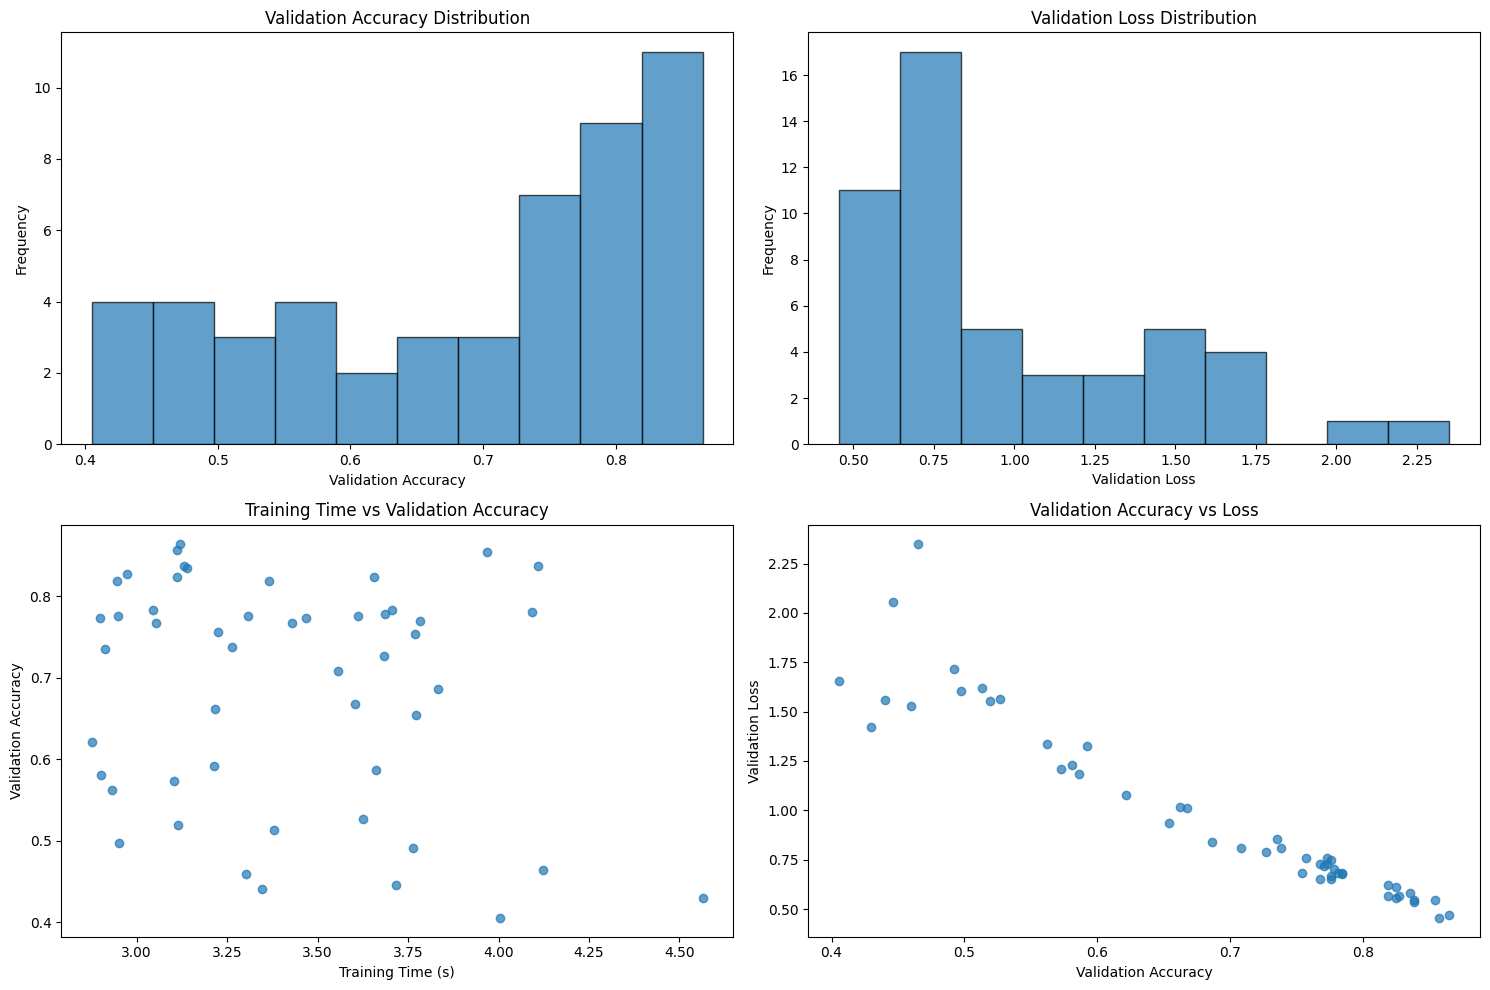

In [50]:
def visualize_tuning_results(results):
    """Visualize hyperparameter tuning results"""

    if not results:
        print("No results to visualize")
        return

    # Extract data for visualization
    val_accuracies = [r["val_accuracy"] for r in results]
    val_losses = [r["val_loss"] for r in results]
    training_times = [r["training_time"] for r in results]

    # Create visualizations
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))

    # Validation accuracy distribution
    axes[0, 0].hist(val_accuracies, bins=10, alpha=0.7, edgecolor="black")
    axes[0, 0].set_title("Validation Accuracy Distribution")
    axes[0, 0].set_xlabel("Validation Accuracy")
    axes[0, 0].set_ylabel("Frequency")

    # Validation loss distribution
    axes[0, 1].hist(val_losses, bins=10, alpha=0.7, edgecolor="black")
    axes[0, 1].set_title("Validation Loss Distribution")
    axes[0, 1].set_xlabel("Validation Loss")
    axes[0, 1].set_ylabel("Frequency")

    # Training time vs accuracy
    axes[1, 0].scatter(training_times, val_accuracies, alpha=0.7)
    axes[1, 0].set_title("Training Time vs Validation Accuracy")
    axes[1, 0].set_xlabel("Training Time (s)")
    axes[1, 0].set_ylabel("Validation Accuracy")

    # Accuracy vs loss
    axes[1, 1].scatter(val_accuracies, val_losses, alpha=0.7)
    axes[1, 1].set_title("Validation Accuracy vs Loss")
    axes[1, 1].set_xlabel("Validation Accuracy")
    axes[1, 1].set_ylabel("Validation Loss")

    plt.tight_layout()
    plt.show()


# Visualize results
visualize_tuning_results(tuning_results)

## Train Best Model

In [51]:
def train_best_model(best_params, X_train, y_train, X_val, y_val, X_test, y_test):
    """Train the best model with optimal hyperparameters"""

    input_shape = X_train.shape[1]
    num_classes = y_train.shape[1]

    # Create best model
    best_model = create_model(
        hidden_layers=best_params["hidden_layers"],
        hidden_units=best_params["hidden_units"],
        dropout_rate=best_params["dropout_rate"],
        activation=best_params["activation"],
        input_shape=input_shape,
        num_classes=num_classes,
    )

    # Compile best model
    best_model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=best_params["learning_rate"]),
        loss="categorical_crossentropy",
        metrics=["accuracy"],
    )

    # Define callbacks
    callbacks = [
        keras.callbacks.EarlyStopping(
            monitor="val_loss", patience=15, restore_best_weights=True
        ),
        keras.callbacks.ReduceLROnPlateau(
            monitor="val_loss", factor=0.5, patience=5, min_lr=0.0001
        ),
    ]

    # Train best model
    print("Training best model...")
    best_history = best_model.fit(
        X_train,
        y_train,
        validation_data=(X_val, y_val),
        epochs=50,
        batch_size=best_params["batch_size"],
        callbacks=callbacks,
        verbose=1,
    )

    # Evaluate on test set
    test_loss, test_accuracy = best_model.evaluate(X_test, y_test, verbose=0)
    print(f"Best Model Test Accuracy: {test_accuracy:.4f}")
    print(f"Best Model Test Loss: {test_loss:.4f}")

    return best_model, best_history


# Train best model
if best_result:
    best_model, best_history = train_best_model(
        best_result["params"],
        X_train,
        y_train_cat,
        X_val,
        y_val_cat,
        X_test,
        y_test_cat,
    )

Training best model...
Epoch 1/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.3583 - loss: 1.9522 - val_accuracy: 0.5541 - val_loss: 1.5045 - learning_rate: 0.0010
Epoch 2/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6020 - loss: 1.2064 - val_accuracy: 0.6324 - val_loss: 1.2159 - learning_rate: 0.0010
Epoch 3/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6480 - loss: 0.9993 - val_accuracy: 0.7135 - val_loss: 0.9591 - learning_rate: 0.0010
Epoch 4/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7329 - loss: 0.7860 - val_accuracy: 0.7622 - val_loss: 0.8143 - learning_rate: 0.0010
Epoch 5/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7681 - loss: 0.6905 - val_accuracy: 0.7865 - val_loss: 0.7187 - learning_rate: 0.0010
Epoch 6/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8005 - loss: 0.6141 - val_accuracy: 0.7703 - val_loss: 0.6931 - learning_rate: 0.0010
Epoch 7/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7960 - loss: 

## Save Best Model

In [52]:
# Save best model
if best_result:
    best_model.save("best_emotion_model.keras")
    print("Best model saved successfully!")

    # Save hyperparameters
    import json

    with open("best_hyperparameters.json", "w") as f:
        json.dump(best_result["params"], f, indent=2)
    print("Best hyperparameters saved to JSON file")

Best model saved successfully!
Best hyperparameters saved to JSON file


## Evaluate Best Model

In [53]:
y_pred = best_model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true_classes = np.argmax(y_test_cat, axis=1)


print(f"Predictions shape: {y_pred.shape}")
print(f"Predicted classes: {y_pred_classes[:10]}")
print(f"True classes ----: {y_true_classes[:10]}")

12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
Predictions shape: (370, 8)
Predicted classes: [0 3 5 4 7 4 5 6 0 2]
True classes ----: [0 3 5 4 7 4 5 6 0 5]


In [54]:
# Load reverse mappings
with open("ravdess_reverse_mapping.json", "r") as f:
    reverse_mapping = json.load(f)


print("Reverse label mappings:")
for code, emotion in reverse_mapping.items():
    print(f"{code}: {emotion}")

Reverse label mappings:
0: Neutral
1: Calm
2: Happy
3: Sad
4: Angry
5: Fearful
6: Disgust
7: Surprised


### Confusion Matrix

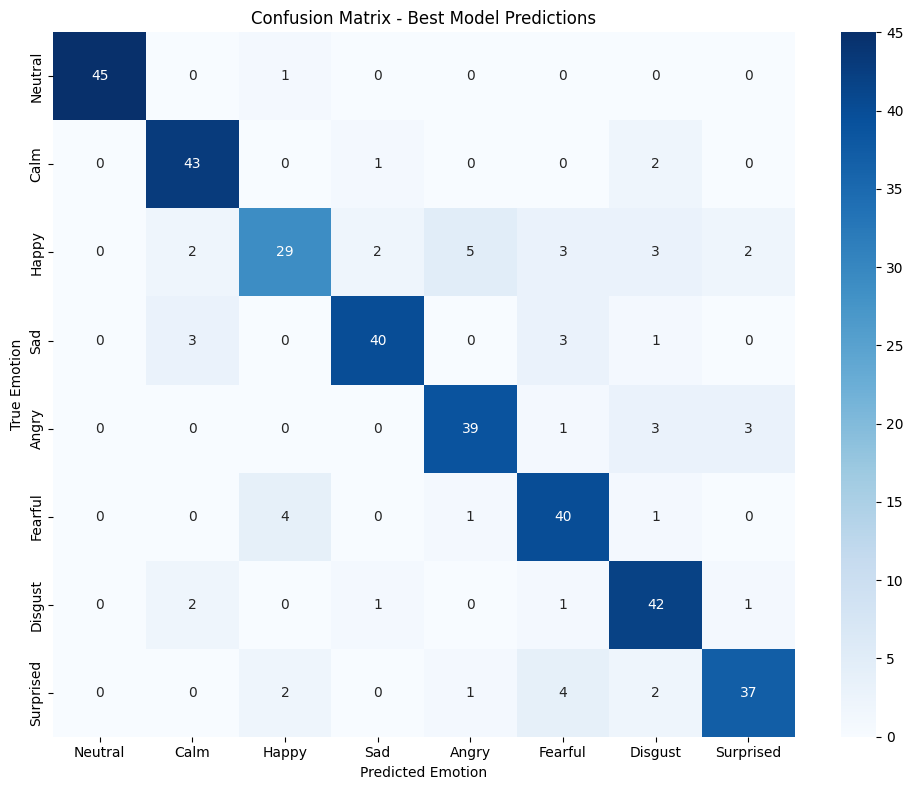

In [55]:
# Create confusion matrix
cm = confusion_matrix(y_true_classes, y_pred_classes)

# Plot confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=list(reverse_mapping.values()),
    yticklabels=list(reverse_mapping.values()),
)
plt.title("Confusion Matrix - Best Model Predictions")
plt.xlabel("Predicted Emotion")
plt.ylabel("True Emotion")
plt.tight_layout()
plt.show()

### Classification Report

In [56]:
# Generate classification report
report = classification_report(
    y_true_classes, y_pred_classes, target_names=list(reverse_mapping.values())
)
print("Classification Report:")
print(report)

Classification Report:
              precision    recall  f1-score   support

     Neutral       1.00      0.98      0.99        46
        Calm       0.86      0.93      0.90        46
       Happy       0.81      0.63      0.71        46
         Sad       0.91      0.85      0.88        47
       Angry       0.85      0.85      0.85        46
     Fearful       0.77      0.87      0.82        46
     Disgust       0.78      0.89      0.83        47
   Surprised       0.86      0.80      0.83        46

    accuracy                           0.85       370
   macro avg       0.85      0.85      0.85       370
weighted avg       0.85      0.85      0.85       370



### Prediction Confidence Visualization

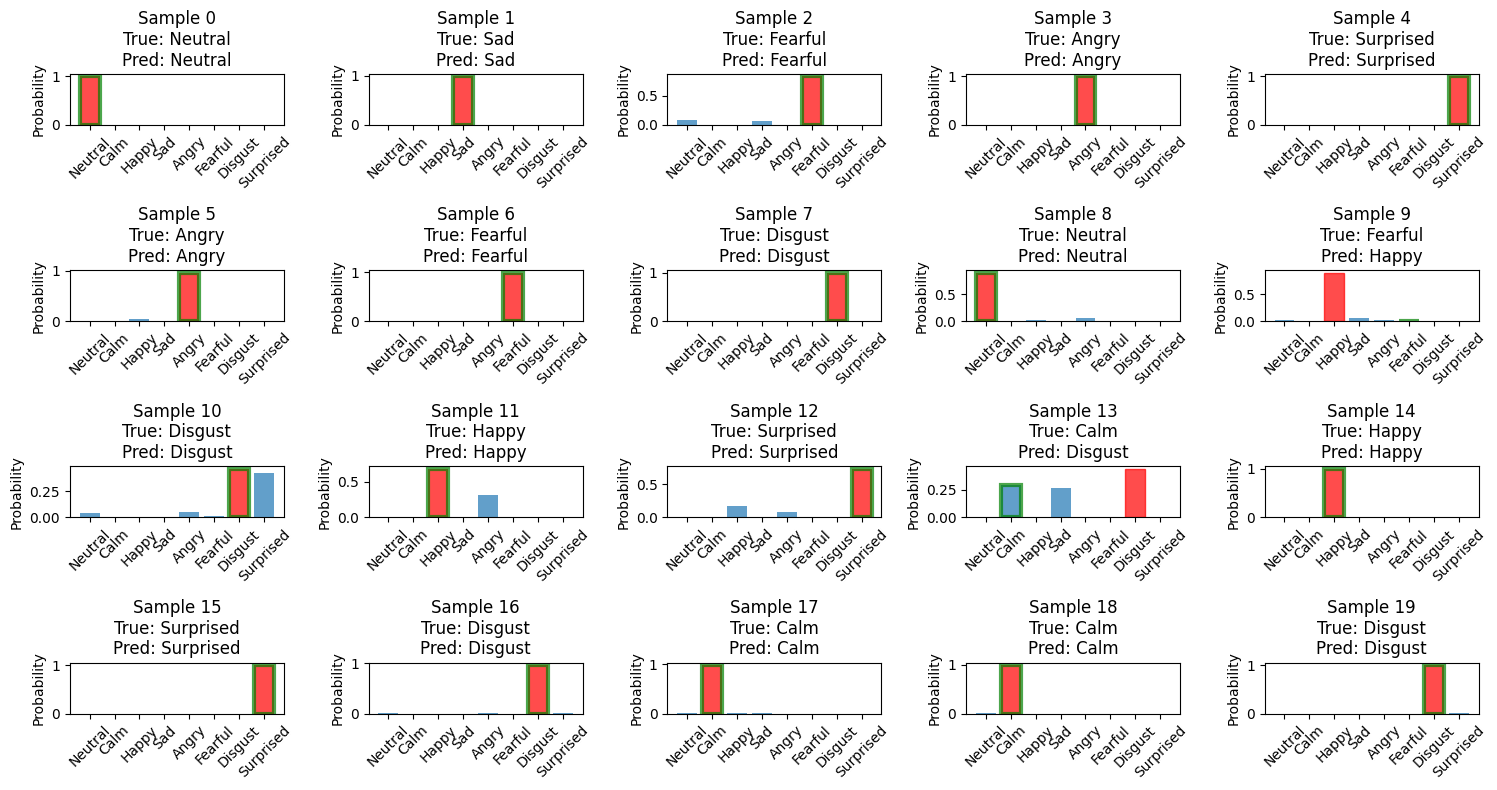

In [57]:
# Plot prediction confidence for first 20 samples
plt.figure(figsize=(15, 8))

# Get top 20 samples
n_samples = min(20, len(X_test))
sample_indices = range(n_samples)

# Create subplot for each sample
for i, idx in enumerate(sample_indices):
    plt.subplot(4, 5, i + 1)

    # Get prediction probabilities
    probs = y_pred[idx]
    emotions = list(reverse_mapping.values())

    # Create bar plot
    bars = plt.bar(emotions, probs, alpha=0.7)

    # Highlight the predicted emotion
    pred_idx = y_pred_classes[idx]
    bars[pred_idx].set_color("red")

    # Add true label
    true_idx = y_true_classes[idx]
    bars[true_idx].set_edgecolor("green")
    bars[true_idx].set_linewidth(3)

    plt.title(f"Sample {idx}\nTrue: {emotions[true_idx]}\nPred: {emotions[pred_idx]}")
    plt.xticks(rotation=45)
    plt.ylabel("Probability")

plt.tight_layout()
plt.show()

### Prediction Distribution

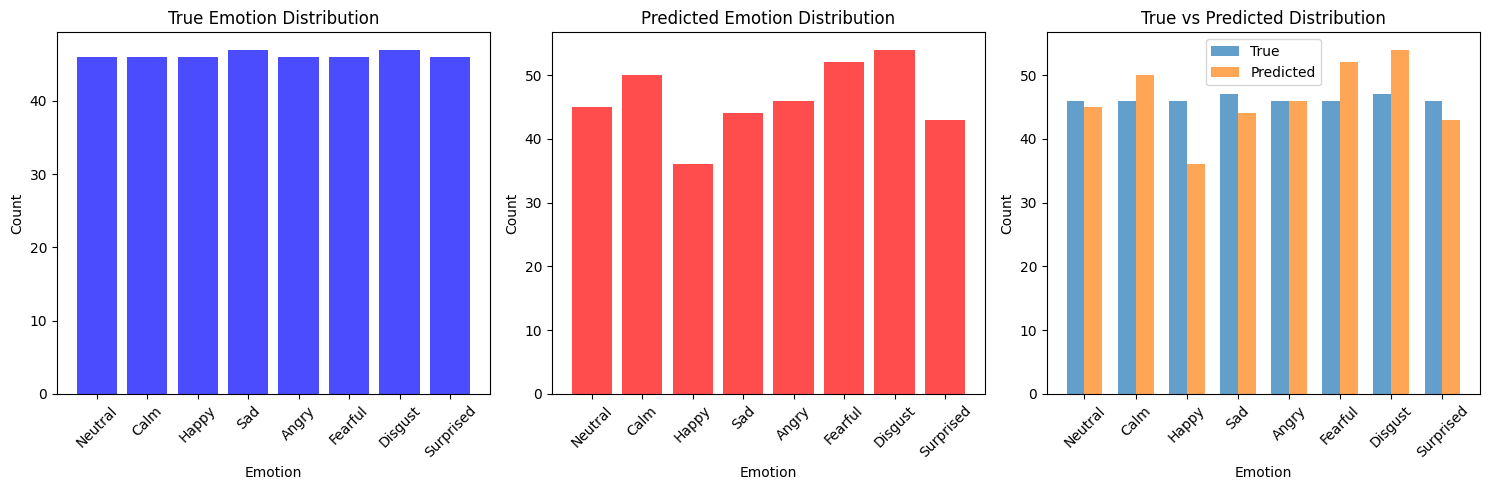

In [58]:
# Plot prediction distribution
plt.figure(figsize=(15, 5))

# True emotion distribution
plt.subplot(1, 3, 1)
true_counts = np.bincount(y_true_classes)
emotions = list(reverse_mapping.values())
plt.bar(emotions, true_counts, alpha=0.7, color="blue")
plt.title("True Emotion Distribution")
plt.xlabel("Emotion")
plt.ylabel("Count")
plt.xticks(rotation=45)

# Predicted emotion distribution
plt.subplot(1, 3, 2)
pred_counts = np.bincount(y_pred_classes)
plt.bar(emotions, pred_counts, alpha=0.7, color="red")
plt.title("Predicted Emotion Distribution")
plt.xlabel("Emotion")
plt.ylabel("Count")
plt.xticks(rotation=45)

# Comparison
plt.subplot(1, 3, 3)
x = np.arange(len(emotions))
width = 0.35
plt.bar(x - width / 2, true_counts, width, label="True", alpha=0.7)
plt.bar(x + width / 2, pred_counts, width, label="Predicted", alpha=0.7)
plt.title("True vs Predicted Distribution")
plt.xlabel("Emotion")
plt.ylabel("Count")
plt.xticks(x, emotions, rotation=45)
plt.legend()

plt.tight_layout()
plt.show()

# Real-time inference

In [61]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
import librosa
import sounddevice as sd
import time


def simple_realtime_emotion(model_path="best_emotion_model.keras"):
    """Ultra-simple real-time emotion recognition with correct features"""

    # Load model
    model = keras.models.load_model(model_path)
    emotions = [
        "Neutral",
        "Calm",
        "Happy",
        "Sad",
        "Angry",
        "Fearful",
        "Disgust",
        "Surprised",
    ]

    print("Simple real-time emotion recognition started!")
    print("Press Ctrl+C to stop")

    try:
        while True:
            # Record 3 seconds of audio
            print("Recording...")
            audio = sd.rec(int(22050 * 3), samplerate=22050, channels=1)
            sd.wait()

            # Extract features (matching training features)
            audio_clean, _ = librosa.effects.trim(audio.flatten(), top_db=20)
            audio_norm = audio_clean / np.max(np.abs(audio_clean))

            # Extract all features like in training
            mfccs = librosa.feature.mfcc(y=audio_norm, sr=22050, n_mfcc=13)
            chroma = librosa.feature.chroma_stft(y=audio_norm, sr=22050)
            spectral_centroids = librosa.feature.spectral_centroid(
                y=audio_norm, sr=22050
            )
            spectral_rolloff = librosa.feature.spectral_rolloff(y=audio_norm, sr=22050)
            zero_crossing_rate = librosa.feature.zero_crossing_rate(audio_norm)

            # Combine features to match training (56 features total)
            features = np.concatenate(
                [
                    np.mean(mfccs, axis=1),  # 13 MFCC means
                    np.std(mfccs, axis=1),  # 13 MFCC stds
                    np.mean(chroma, axis=1),  # 12 chroma means
                    np.std(chroma, axis=1),  # 12 chroma stds
                    [np.mean(spectral_centroids)],  # 1 spectral centroid mean
                    [np.std(spectral_centroids)],  # 1 spectral centroid std
                    [np.mean(spectral_rolloff)],  # 1 spectral rolloff mean
                    [np.std(spectral_rolloff)],  # 1 spectral rolloff std
                    [np.mean(zero_crossing_rate)],  # 1 ZCR mean
                    [np.std(zero_crossing_rate)],  # 1 ZCR std
                ]
            )

            print(f"Feature shape: {features.shape}")

            # Predict emotion
            prediction = model.predict(features.reshape(1, -1), verbose=0)
            emotion_idx = np.argmax(prediction[0])
            confidence = prediction[0][emotion_idx]
            emotion = emotions[emotion_idx]

            print(f"Emotion: {emotion} (confidence: {confidence:.3f})")

    except KeyboardInterrupt:
        print("\nStopped.")


# Run it
simple_realtime_emotion()

Simple real-time emotion recognition started!
Press Ctrl+C to stop
Recording...
Feature shape: (56,)
Emotion: Sad (confidence: 1.000)
Recording...
Feature shape: (56,)
Emotion: Sad (confidence: 1.000)
Recording...
Feature shape: (56,)
Emotion: Sad (confidence: 1.000)
Recording...
Feature shape: (56,)
Emotion: Sad (confidence: 1.000)
Recording...

Stopped.
